<center> <img src="https://miro.medium.com/v2/resize:fit:1200/1*lbDXL0IuitCRz4mpZ7MmfQ.png" width=55% > </center>

<br><br>

<center> 
    <font size="6">Final Lab (Part 2): Image Classification using Convolutional Neural Networks </font>
</center>
<center> 
    <font size="4">Computer Vision 1 University of Amsterdam</font> 
</center>
<center> 
    <font size="4">Due 23:59PM, 24th October, 2025 (Amsterdam time)</font> 
</center>

<br><br>

***

<br><br>

<center>

Student1 ID: 16016327

Student1 Name: Daniel Otero Gomez

Student2 ID: 13710281

Student2 Name: Daniel Amidirad

Student3 ID: 16427556

Student3 Name: Miguel Aldea Mendes

</center>

### **Coding Guidelines**

Your code must be handed in this Jupyter notebook, renamed to **StudentID1_StudentID2_StudentID3.ipynb** before the deadline by submitting it to the Canvas Final Lab: Image Classification Assignment. Please also fill out your names and IDs above.

For full credit, make sure your notebook follows these guidelines:

- Please express your thoughts **concisely**. The number of words does not necessarily correlate with how well you understand the concepts.
- Understand the problem as much as you can. When answering a question, provide evidence (qualitative and/or quantitative results, references to papers, figures, etc.) to support your arguments. Not everything might be explicitly asked for, so think about what might strengthen your arguments to make the notebook self-contained and complete.
- Tables and figures must be accompanied by a **brief** description. Add a number, a title, and, if applicable, the name and unit of variables in a table, and name and unit of axes and legends in a figure.

**Late submissions are not allowed.** Assignments submitted after the strict deadline will not be graded. In case of submission conflicts, TAs’ system clock is taken as reference. We strongly recommend submitting well in advance to avoid last-minute system failure issues.

**Environment:** Since this is a project-based assignment, you are free to use any feature descriptor and machine learning tools (e.g., K-means, SVM). You should use Python for your implementation. You are free to use any Python library for this assignment, but make sure to provide a conda environment file!

**Plagiarism Note:** Keep in mind that plagiarism (submitted materials which are not your work) is a serious offense and any misconduct will be addressed according to university regulations. This includes using generative tools such as ChatGPT.

**Ensure that you save all results/answers to the questions (even if you reuse some code).**

### **Report Preparation**

Your tasks include the following:

1. **Report Preparation:** For both parts of the final project, students are expected to prepare a report. The report should include all details on implementation approaches, analysis of results for different settings, and visualizations illustrating experiments and performance of your implementation. Grading will be based on the report, so it should be as self-contained as possible. If the report contains faulty results or ambiguities, TAs can refer to your code for clarification. 

2. **Explanation of Results:** Do not just provide numbers without explanation. Discuss different settings to show your understanding of the material and processes involved.

3. **Quantitative Evaluation:** For quantitative evaluation, you are expected to provide the results based on performance (accuracy, learning loss and learning curves). 

4. **Aim:** Understand the basic Image Classification pipeline using Convolutional Neural Nets (CNN's).

5. **Working on Assignments:** Students should work in assigned groups for **two** weeks. Any questions can be discussed on ED.

    - **Submission:** Submit your source code and report together in a zip file (`ID1_ID2_ID3_part2.zip`). The report should be a maximum of 10 pages (single-column, including tables and figures, excluding references and appendix). Express thoughts concisely. Tables and figures must be accompanied by a description. Number them and, if applicable, name variables in tables, and label axes in figures.

6. **Hyperparameter Search:** In your experiments, remember to perform a hyperparameter search to find the optimal settings for your model(s). Clearly document the search process, the parameters you explored, and how they influenced the performance of your model.

8. **Format and Testing:** The report should be in **PDF format**, and the code in **.ipynb format**. Test that all functionality works as expected in the notebook.

### **Overview**

- [Section 1: Image Classification on CIFAR-100 (0 points)](#section-1)
- [Section 2: Visualizing CIFAR-100 Classes and Subclasses (3 points)](#section-2)
- [Section 3: TwoLayerNet Architecture (2 points)](#section-3)
- [Section 4: ConvNet Architecture (2 points)](#section-4)
- [Section 5: Preparation of Training (7 points)](#section-5)
- [Section 6: Training the Networks (5 points)](#section-6)
- [Section 7: Setting Up the Hyperparameters (14 points)](#section-7)
- [Section 8: Visualizing the STL-10 Dataset and Preparing the Data Loader (3 points)](#section-8)
- [Section 9: Fine-tuning ConvNet on STL-10 (14 points)](#section-9)
- [Section 10: Bonus Challenge (optional)](#section-10)
- [Section X: Individual Contribution Report (Mandatory)](#section-x)

### **Section 1: Image Classification on CIFAR-100 (0 points)**

The goal of this lab is to implement an image classification system using Convolutional Neural Networks (CNNs) that can identify objects from a set of classes in the [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html). You will implement and compare two different architectures: a simple two-layer network and a ConvNet based on the LeNet architecture.

The CIFAR-100 dataset contains 32x32 pixel RGB images, categorized into 100 different classes. The dataset will be automatically downloaded and loaded using the code provided in this notebook.

You will train and test your classification system using the entire CIFAR-100 dataset. Ensure that the test images are excluded from training to maintain a fair evaluation of the model's performance.

In [139]:
import os
from pathlib import Path
from datetime import datetime
import random
import math
import json

## pytorch library
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision import datasets as tv_datasets
from torchinfo import summary
from torch.utils.data import DataLoader, Dataset, random_split
from torch.utils.tensorboard import SummaryWriter

## we add some libraries

## data processing
import numpy as np
import pandas as pd

## visualization
import plotly.express as px
import matplotlib.pyplot as plt
from PIL import Image


## higher quality figure output
%config InlineBackend.figure_format = 'svg'

## Machine Learning library
import sklearn as skl

## hyperparameter tuning
import optuna


####################################################################################

# Define the transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  
])

# Load the CIFAR-100 training set
train_set = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)

# Load the CIFAR-100 test set
test_set = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

# Create data loaders for the entire CIFAR-100 dataset
train_data_loader = DataLoader(train_set, shuffle=True)
test_data_loader = DataLoader(test_set, shuffle=False)

# Define CIFAR-100 superclasses and their subclasses
superclasses = {
    'aquatic mammals': ['beaver', 'dolphin', 'otter', 'seal', 'whale'],
    'fish': ['aquarium_fish', 'flatfish', 'ray', 'shark', 'trout'],
    'flowers': ['orchid', 'poppy', 'rose', 'sunflower', 'tulip'],
    'food containers': ['bottle', 'bowl', 'can', 'cup', 'plate'],
    'fruit and vegetables': ['apple', 'mushroom', 'orange', 'pear', 'sweet_pepper'],
    'household electrical devices': ['clock', 'keyboard', 'lamp', 'telephone', 'television'],
    'household furniture': ['bed', 'chair', 'couch', 'table', 'wardrobe'],
    'insects': ['bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'],
    'large carnivores': ['bear', 'leopard', 'lion', 'tiger', 'wolf'],
    'large man-made outdoor things': ['bridge', 'castle', 'house', 'road', 'skyscraper'],
    'large natural outdoor scenes': ['cloud', 'forest', 'mountain', 'plain', 'sea'],
    'large omnivores and herbivores': ['camel', 'cattle', 'chimpanzee', 'elephant', 'kangaroo'],
    'medium-sized mammals': ['fox', 'porcupine', 'possum', 'raccoon', 'skunk'],
    'non-insect invertebrates': ['crab', 'lobster', 'snail', 'spider', 'worm'],
    'people': ['baby', 'boy', 'girl', 'man', 'woman'],
    'reptiles': ['crocodile', 'dinosaur', 'lizard', 'snake', 'turtle'],
    'small mammals': ['hamster', 'mouse', 'rabbit', 'shrew', 'squirrel'],
    'trees': ['maple_tree', 'oak_tree', 'palm_tree', 'pine_tree', 'willow_tree'],
    'vehicles 1': ['bicycle', 'bus', 'motorcycle', 'pickup_truck', 'train'],
    'vehicles 2': ['lawn_mower', 'rocket', 'streetcar', 'tank', 'tractor']
}

# List of all CIFAR-100 classes
classes = ('apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 
           'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
           'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
           'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
           'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
           'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
           'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea',
           'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 
           'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 
           'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm')

# Create a mapping of class names to their indices
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

# Create a mapping of superclasses to their corresponding class indices
superclass_to_indices = {supcls: [class_to_idx[cls] for cls in subclasses] for supcls, subclasses in superclasses.items()}

print("Data loaders for CIFAR-100 are ready for use.")

Files already downloaded and verified
Files already downloaded and verified
Data loaders for CIFAR-100 are ready for use.


In [140]:
## save random image from dataset
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title('Sample images')
    plt.savefig('samples.svg', format="svg", bbox_inches="tight")
    plt.show()

<a id="section-2"></a>
### **Section 2: Visualizing CIFAR-100 Classes and Subclasses (3 points)**

In this section, you will implement a function to visualize the CIFAR-100 dataset, including **all** superclasses and their corresponding subclasses. Your implementation should provide a clear and organized overview of the dataset's diversity.

You add the figure(s) to appendix of your report and refer to it in the main text.

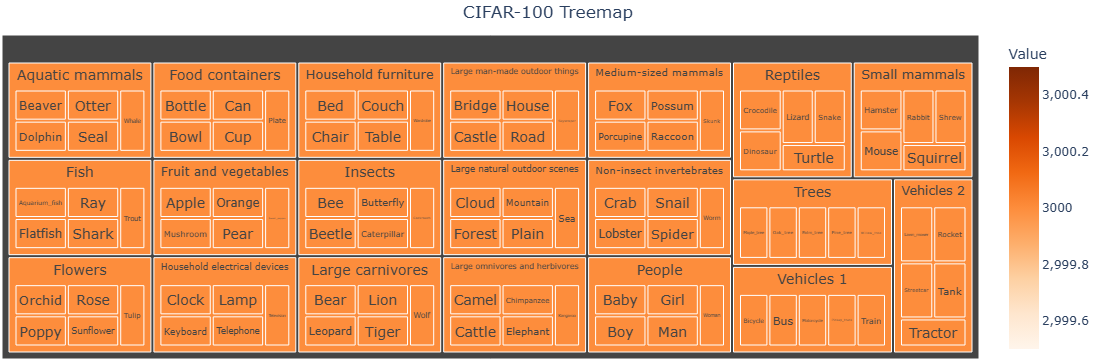

In [141]:
# YOUR CODE HERE
## define a function to visualize CIFAR_100 dataset

def visualize_sub_super(superclasses, train_set, test_set, classes):
    """
    superclasses: dict[superclass -> list of subclass names]
    train_set, test_set: iterable of (image, label_index)
    classes: list of CIFAR-100 class names in label index order
    """

    # Map label index (superclasses and their subclasses)
    label_to_super = {}
    for sup, subs in superclasses.items():
        for sub in subs:
            idx = classes.index(sub)  
            label_to_super[idx] = sup

    # Initialize the counters in train and test set
    train_counts = {sup: 0 for sup in superclasses}
    test_counts  = {sup: 0 for sup in superclasses}

    # Count the number of samples in the train and test set
    for _, label in train_set:
        sup = label_to_super.get(label)
        if sup is not None:
            train_counts[sup] += 1

    for _, label in test_set:
        sup = label_to_super.get(label)
        if sup is not None:
            test_counts[sup] += 1

    # Create a DataFrame
    ## First we build the rows for DataFrame
    rows = []
    for sup, subs in superclasses.items():
        total = train_counts[sup] + test_counts[sup]
        for sub in subs:
            rows.append({
                "Superclass": sup.capitalize(),
                "Subclass": sub.capitalize(),
                "Value": total,
                "Train Count": train_counts[sup],
                "Test Count": test_counts[sup],
            })

    df = pd.DataFrame(rows)

    # Create the Treemap or Sunburst or other hierarchical plot
    ## path -> gives the hierarchy
    fig = px.treemap(
        df,
        path=["Superclass", "Subclass"],
        values="Value",
        title="CIFAR-100 Treemap",
        color="Value",
        color_continuous_scale="Oranges",
        hover_data=["Train Count", "Test Count"],
    )
    fig.update_layout(margin=dict(t=35, l=2, r=2, b=1), title_x=0.5) ## update
    fig.update_traces(textposition="middle center", textfont_size=14) ## text size and position in the figure
    fig.write_image("hierq.svg", width=1000, height=600, scale=1)  # SVG
    fig.write_image("hierq.pdf", width=800, height=500, scale=1)
    fig.show()  ## show the treemap

# Call the function:
visualize_sub_super(superclasses, train_set, test_set, classes)

# and show treemap

<a id="section-3"></a>
### **Section 3: TwoLayerNet Architecture (2 points)**

In this section, you will implement the architecture of a fully connected neural network called `TwoLayerNet`, consisting of two fully connected layers with a ReLU activation in between. The network accepts an input size of 3x32x32 (CIFAR-100 image), a specified hidden layer size, and the number of output classes. In the `__init__` method, define the first fully connected layer that maps the input size to the hidden size, and the second fully connected layer that maps the hidden size to the number of classes. 

Ensure to call the parent class constructor using `super(TwoLayerNet, self).__init__()`. In the `forward` method, flatten the input tensor, pass it through the first layer with ReLU activation, and then through the second layer to obtain the final scores.

**Note:** You are allowed to modify the provided function definitions as needed.

In [142]:
class TwoLayerNet(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        '''
        Initializes the two-layer neural network model.

        Args:
            input_size (int): The size of the input features.
            hidden_size (int): The size of the hidden layer.
            num_classes (int): The number of classes in the dataset.
        '''
        # YOUR CODE HERE
        ### define network architecture by using "nn.Sequential"
        
        super(TwoLayerNet, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),  # layer 1 - fully connected 
            nn.ReLU(),                           # non-linear activation function
            nn.Linear(hidden_size, num_classes)  # layer 2 - fully connected
        )

    def forward(self, x):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''
       # YOUR CODE HERE
       ### flatten the input tensor x (we obtain a 2D tensor (batch_size, features))
               
        return self.net(x.flatten(1))


<a id="section-4"></a>
### **Section 4: ConvNet Architecture (2 points)**

In this section, you will implement a convolutional neural network inspired by the structure of [LeNet-5](https://ieeexplore.ieee.org/document/726791). The network processes color images using three convolutional layers followed by two fully connected layers. Since you need to feed color images into this network, determine the kernel size of the first convolutional layer. Additionally, calculate the number of trainable parameters in the "F6" layer, providing the calculation process.

In [143]:
class ConvNet(nn.Module):

    def __init__(self, num_classes = 100):
        '''	
        Initializes the convolutional neural network model.

        Args:
            num_classes : the number of classes
        '''

        # YOUR CODE HERE
        # Initialize the PyTorch module
        super().__init__()

        # (Sequential) Feature extraction block (convolution + pooling) 
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, 5),      # Conv1: input RGB (3 channels), applies 6 filters → [3, 32, 32] reduced to [6, 28, 28]
            nn.Tanh(),               # Non-linear activation
            nn.AvgPool2d(2, 2),      # Average Pooling 1: reduce size by half (stride S=2) → [6, 14, 14]

            nn.Conv2d(6, 16, 5),     # Conv2: 6 input channels → applies 16 filters: [6, 14, 14] → [16, 10, 10]
            nn.Tanh(),               # Non-linear activation function
            nn.AvgPool2d(2, 2),      # Average Pooling 2: reduce size by half → [16, 5, 5]

            nn.Conv2d(16, 120, 5),   # Conv3: 16 input channels → applies 120 filters: [16, 5, 5] → [120, 1, 1]
            nn.Tanh()                # Non-linear activation function
        )

        # Classification block (fully connected (FC) layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),               # Flatten feature map, convert 4D tensors to 2D -> [batch, features=120]
            nn.Linear(120, 84),         # FC1: hidden layer with 84 neurons
            nn.Tanh(),                  # Non-linear activation function
            nn.Linear(84, num_classes)   # FC2: output logits for each class (100)
        )

    def forward(self, x):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''

        # YOUR CODE HERE
        # Pass input through convolutional layers
        x = self.features(x)

        # Pass result through classifier to get class scores
        return self.classifier(x)


<a id="section-5"></a>
### **Section 5: Preparation of Training (7 points)**

In this section, you will create a custom dataset class to load the CIFAR-100 data, define a transform function for data augmentation, and set up an optimizer for training. While the previous section utilized the built-in CIFAR-100 class from `torchvision`, in practice, you often need to prepare datasets manually. Here, you will implement the `CIFAR100_loader` class to handle the dataset and use `DataLoader` to make it iterable. You will also define a transform function for data augmentation and an optimizer for updating the model's parameters.

In [144]:
# Reproducibility

def set_seed(seed=1337):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed); torch.backends.cudnn.deterministic = True
set_seed(1337)

In [145]:
class CIFAR100_loader(Dataset):
    
    def __init__(self, root, train=True, transform=None, download=False):
        '''
        Initializes the CIFAR-100 dataset loader.

        Args:
            root (str): The root directory to store the dataset.
            train (bool): If True, loads the training data; otherwise, loads the test data.
            transform (callable, optional): The data transformations to apply.
            download (bool): If True, downloads the dataset if it is not already available.
        '''
    
        # YOUR CODE HERE
        # Load CIFAR-100 (torchvision) as the underlying dataset
        
        self.dataset = datasets.CIFAR100(root=root, train=train, 
                                         transform=transform, download=download)
        
        # Store parameters 
        self.transform = transform
        self.train = train

    def __len__(self):
        '''
        Returns the number of samples in the dataset.

        Returns:
            int: The number of samples in the dataset.
        '''

        # YOUR CODE HERE
        
        return len(self.dataset)
    

    def __getitem__(self, idx):
        '''
        Retrieves a sample from the dataset at the specified index.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            tuple: A tuple containing the image and label tensors.
        '''

        # YOUR CODE HERE
        
        # Get one image-label pair
        image, label = self.dataset[idx]
        return image, label

In [146]:
def create_transforms():
    '''
    Creates the data transformations for the CIFAR-100 dataset.

    Returns:
        torchvision.transforms.Compose: The data transformations for the dataset.
    '''

    # YOUR CODE HERE
    
    # define mean and std for normalization.
    mean = (0.5, 0.5, 0.5)   # dataset channel means
    std  = (0.5, 0.5, 0.5)   # dataset channel stds

    transf = transforms.Compose([
        transforms.Resize((32, 32)),     ## resize images 
        transforms.ToTensor(),           ## convert PIL image to tensor
        transforms.Normalize(mean, std)  ## normalize pixel values
    ])

    return transf
    

In [147]:
def create_optimizer(model, learning_rate=0.001):
    '''
    Creates an optimizer for the model.

    Args:
        model (torch.nn.Module): The neural network model.
        learning_rate (float): The learning rate for the optimizer.

    Returns:
        torch.optim.Adam: The optimizer for the model.
    '''

    # YOUR CODE HERE
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, eps=1e-8, amsgrad=True, weight_decay=0)
    
    return optimizer

<a id="section-6"></a>
### **Section 6: Training the Networks (5 points)**

In this section, you will complete the `train` function and use it to train both the `TwoLayerNet` and `ConvNet` models. You will use the custom `CIFAR100_loader`, transform function, and optimizer function that you implemented. The goal is to compare the performance of the two models on the CIFAR-100 dataset.

In [148]:
def validate(net, testloader):
    '''
    Validates the model on the test dataset.

    Args:
        net (torch.nn.Module): The neural network model.
        testloader (torch.utils.data.DataLoader): The data loader for the test dataset.

    Returns:
        float: The accuracy of the model on the test dataset.
    '''

    # Set the model to evaluation mode
    net.eval()

    # Determine the device to run the model on
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    correct, total = 0, 0

    # Disable gradient computation
    with torch.no_grad():

        # Iterate over the test dataset
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the test images: {accuracy:.2f} %')

    return accuracy

In [149]:
def validate_per_class(net, testloader, classes):
    '''
    Validates the model on the test dataset per class.

    Args:
        net (torch.nn.Module): The neural network model.
        testloader (torch.utils.data.DataLoader): The data loader for the test dataset.
        classes (tuple): The tuple of class names.

    Returns:
        None
    '''

    # Set the model to evaluation mode
    net.eval()

    # Determine the device to run the model on
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class_correct = [0. for _ in range(len(classes))]
    class_total = [0. for _ in range(len(classes))]

    # Disable gradient computation
    with torch.no_grad():

        # Iterate over the test dataset
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs, 1)
            correct_predictions = (predicted == labels).squeeze()

            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += correct_predictions[i].item()
                class_total[label] += 1

    for i, class_name in enumerate(classes):
        accuracy = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
        print(f'Accuracy of {class_name:5s} : {accuracy:.2f} %')

In [150]:
def train(net, train_loader, test_loader, criterion, optimizer, epochs, device=None):
    '''
    Trains the neural network model.

    Args:
        net (torch.nn.Module): The neural network model.
        train_loader (torch.utils.data.DataLoader): The data loader for the training dataset.
        criterion (torch.nn.Module): The loss function.
        optimizer (torch.optim.Optimizer): The optimizer for the model.
        epochs (int): The number of epochs to train the model.

    Returns:
        None
    '''
    # YOUR CODE HERE
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net.to(device)

    
    model_name = net.__class__.__name__
    ts = datetime.now().strftime("%Y-%m-%d")
    log_dir = Path("runs") / "CIFAR100" / model_name / ts
    log_dir.mkdir(parents=True, exist_ok=True)
    writer = SummaryWriter(log_dir=str(log_dir))
    print(f"[TB] Logging to: {log_dir.resolve()}")

    train_losses = []  # define a list to store losses -> for plotting effect 
    train_accs = [] # list for accuracy
    #test_losses = []
    test_accs = []

    for ep in range(1, epochs + 1):
        net.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / max(total, 1)
        epoch_acc = 100.0 * correct / max(total, 1)

        test_acc = validate(net, test_loader)

        # Log to TensorBoard
        writer.add_scalar("Loss/Train", epoch_loss, ep)
        writer.add_scalar("Acc/Train", epoch_acc, ep)
        writer.add_scalar("Acc/Test",  test_acc, ep)

        print(
            f"Epoch {ep:03d}/{epochs} | "
            f"train_loss={epoch_loss:.4f} "
            f"train_acc={epoch_acc:.2f}%  "
            f"test_acc={test_acc:.2f}%  "
        )

        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)
        #test_losses.append(test_loss)
        test_accs.append(test_acc)

        writer.flush()
        writer.close()

    return net, train_losses, train_accs, test_accs


First, initialize the datasets and data loaders for both models.

In [151]:
## define some hyperparameter values valid for both models

### Case 1
bs = 1024  # batch size
lr = 0.005  #learning rate
epochs = 30

##############################################
### Case 2
#bs = 512  # batch size
#lr = 0.02  #learning rate
#epochs = 30

In [152]:
## initialize datasets

tfms = create_transforms()

root = "./data"

## train and test set
train_set = CIFAR100_loader(root=root, train=True,  download=True, transform= tfms)
test_set  = CIFAR100_loader(root=root, train=False, download=True, transform= tfms)

# data loader
train_loader = DataLoader(train_set, batch_size=bs, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=bs, shuffle=False, pin_memory=True)


Files already downloaded and verified
Files already downloaded and verified


Next, train the TwoLayerNet model on the CIFAR-100 dataset using the training data loader.

In [153]:
# TwoLayerNet - baseline model

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model and move it to the appropriate device
twolayer = TwoLayerNet(3 * 32 * 32, 512, 100).to(device)

# Optimizer: use the function defined before
optimizer_tln = create_optimizer(twolayer, learning_rate=lr)

# define loss function
criterion = nn.CrossEntropyLoss()

# Train the model
twolayer, train_losses, train_accs, test_accs = train(twolayer, train_loader, test_loader, criterion, optimizer_tln, epochs=epochs, device=device)


# Save weights + full model
Path("checkpoints").mkdir(parents=True, exist_ok=True)
torch.save(twolayer.state_dict(), "checkpoints/twolayernet_weights.pth")
torch.save(twolayer,            "checkpoints/twolayernet_model.pth")
print("[SAVE] TwoLayerNet -> checkpoints/twolayernet_weights.pth & twolayernet_model.pth")

[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNet\2025-10-25
Accuracy of the network on the test images: 15.17 %
Epoch 001/30 | train_loss=4.5079 train_acc=10.75%  test_acc=15.17%  
Accuracy of the network on the test images: 19.42 %
Epoch 002/30 | train_loss=3.4788 train_acc=19.80%  test_acc=19.42%  
Accuracy of the network on the test images: 20.92 %
Epoch 003/30 | train_loss=3.2401 train_acc=24.13%  test_acc=20.92%  
Accuracy of the network on the test images: 21.19 %
Epoch 004/30 | train_loss=3.0979 train_acc=26.75%  test_acc=21.19%  
Accuracy of the network on the test images: 21.21 %
Epoch 005/30 | train_loss=2.9718 train_acc=29.62%  test_acc=21.21%  
Accuracy of the network on the test images: 21.99 %
Epoch 006/30 | train_loss=2.8565 train_acc=32.01%  test_acc=21.99%  
Accuracy of the network on the test images: 22.35 %
Epoch 007/30 | train_loss=2.7863 train_acc=33.61%  test_acc=22.35%  
Accur

In [154]:
### count number of trainable parameters
model_name = "TwoLayerNet"  

model_eval = twolayer 

num_params = sum(p.numel() for p in model_eval.parameters() if p.requires_grad)
print(f"\n Model selected: {model_name}")
print(f" Trainable parameters: {num_params:,}\n")


 Model selected: TwoLayerNet
 Trainable parameters: 1,624,676



Finally, train the ConvNet model on the CIFAR-100 dataset using the training data loader.

In [155]:

# ConvNet - baseline model

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model and move it to the appropriate device
convnet = ConvNet(num_classes=100).to(device)

# Optimizer: use the function defined before
optimizer_cnn = create_optimizer(convnet, learning_rate=lr)

# Loss function
criterion = nn.CrossEntropyLoss()

# Train ConvNet model
convnet, train_losses_c, train_accs_c, test_accs_c = train(convnet, train_loader, test_loader, criterion, optimizer_cnn, epochs, device=device)

# Save weights + full model
Path("checkpoints").mkdir(parents=True, exist_ok=True)
torch.save(convnet.state_dict(), "checkpoints/convnet_weights.pth")
torch.save(convnet,            "checkpoints/convnet_model.pth")
print("[SAVE] ConvNet -> checkpoints/convnet_weights.pth & convnet_model.pth")

[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\ConvNet\2025-10-25
Accuracy of the network on the test images: 12.68 %
Epoch 001/30 | train_loss=4.1029 train_acc=8.16%  test_acc=12.68%  
Accuracy of the network on the test images: 16.58 %
Epoch 002/30 | train_loss=3.6660 train_acc=14.96%  test_acc=16.58%  
Accuracy of the network on the test images: 18.83 %
Epoch 003/30 | train_loss=3.4599 train_acc=18.32%  test_acc=18.83%  
Accuracy of the network on the test images: 20.59 %
Epoch 004/30 | train_loss=3.3133 train_acc=20.94%  test_acc=20.59%  
Accuracy of the network on the test images: 21.72 %
Epoch 005/30 | train_loss=3.2058 train_acc=22.74%  test_acc=21.72%  
Accuracy of the network on the test images: 22.81 %
Epoch 006/30 | train_loss=3.1121 train_acc=24.47%  test_acc=22.81%  
Accuracy of the network on the test images: 23.26 %
Epoch 007/30 | train_loss=3.0521 train_acc=25.57%  test_acc=23.26%  
Accuracy o

_____________

Some plots to compare the performance of the models
___________________


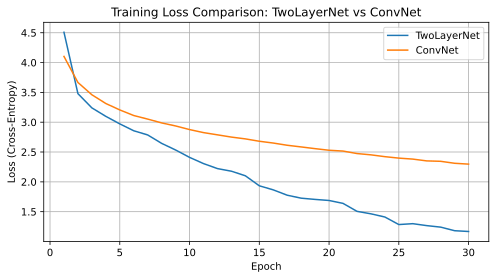

In [156]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(train_losses)+1), train_losses, label='TwoLayerNet')
plt.plot(np.arange(1, len(train_losses_c)+1), train_losses_c, label='ConvNet')
plt.title("Training Loss Comparison: TwoLayerNet vs ConvNet")
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("2layers_ConvNet_loss.svg", format="svg", bbox_inches="tight")
plt.show()

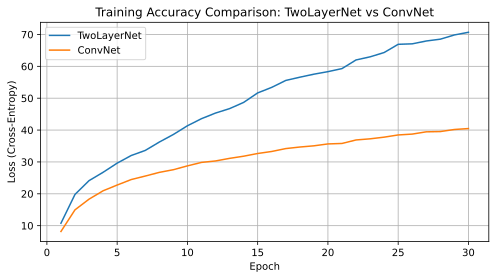

In [157]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(train_accs)+1), train_accs, label='TwoLayerNet')
plt.plot(np.arange(1, len(train_accs_c)+1), train_accs_c, label='ConvNet')
plt.title("Training Accuracy Comparison: TwoLayerNet vs ConvNet")
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("2layers_ConvNet_accs_train.svg", format="svg", bbox_inches="tight")
plt.show()

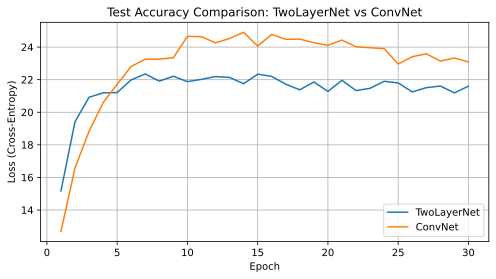

In [158]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(test_accs)+1), test_accs, label='TwoLayerNet')
plt.plot(np.arange(1, len(test_accs_c)+1), test_accs_c, label='ConvNet')
plt.title("Test Accuracy Comparison: TwoLayerNet vs ConvNet")
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("2layers_ConvNet_test_accs_test.svg", format="svg", bbox_inches="tight")
plt.show()

In [138]:
## Count the number of trainable parameters

model_name = "ConvNet"  
model_eval = convnet 

num_params = sum(p.numel() for p in model_eval.parameters() if p.requires_grad)
print(f"\n Model selected: {model_name}")
print(f" Trainable parameters: {num_params:,}\n")



 Model selected: ConvNet
 Trainable parameters: 780,516



<a id="section-7"></a>
### **Section 7: Setting Up the Hyperparameters (14 points)**

In this section, you will experiment with both the `ConvNet` and `TwoLayerNet` models by setting up and tuning the hyperparameters to achieve the highest possible accuracy. You have the flexibility to modify the training process, including the `train` function, `DataLoader`, `transform` functions, and optimizer as needed.

1. Adjust the hyperparameters, including learning rate, batch size, number of epochs, optimizer, weight decay, and transform function to improve the performance of both networks. Modify the training procedure and architecture as necessary. You can also add components like Batch Normalization layers.
2. Add two more layers to both `TwoLayerNet` and `ConvNet`. You can decide the size and placement of these layers. Evaluate if these changes result in higher performance and explain your findings.
3. Show the final results and describe the modifications made to enhance performance. Discuss the impact of hyperparameter tuning on both `TwoLayerNet` and `ConvNet`.
4. Compare the two networks in terms of architecture, performance, and learning rates. Provide a detailed explanation of the differences observed.

**Note:** Do not use external pre-trained networks and limit additional convolutional layers to a maximum of three beyond the original architecture.

______________________

## Question 7.1. Hyperparameter tuning

______________
- For the baseline models (TwoLayerNet and ConvNet) defined in Section 6, we employ hyperparameter tuning to increase accuracy and reduce overfitting.
    - Simple Grid Search
    - Optuna

In [24]:
### simple grid search
### values in grid based on initial experimentation (trial and error) and literature

num_classes = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()

# original datasets
base_train_ds = train_loader.dataset
base_test_ds  = test_loader.dataset

#  choose model and optimizer 
def make_model(name):
    if name.lower() == "twolayernet":
        return TwoLayerNet(3*32*32, 512, num_classes).to(device)
    return ConvNet(num_classes=num_classes).to(device)

def make_optimizer(model, name, lr, wd):
    name = name.lower()
    if name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=wd)
    if name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    # fallback if you have a factory
    try:
        return create_optimizer(model, learning_rate=lr)
    except Exception:
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=wd)

## loss function
criterion = nn.CrossEntropyLoss()

# define grid 
grid = [
    # model,       opt,     lr,      wd,    epochs,  batch_size
    ("TwoLayerNet","sgd",   0.005,   5e-4,  10,      1024),
    ("TwoLayerNet","adamw", 0.001,   1e-4,  10,      1024),
    ("TwoLayerNet","adamw", 0.0001,  1e-4,  10,      512),
    ("TwoLayerNet","sgd",   0.05,    1e-4,  10,      512),
    ("ConvNet",    "sgd",   0.05,    5e-4,  10,      256),
    ("ConvNet",    "adamw", 0.001,   1e-4,  10,      256),
    ("ConvNet",    "sgd", 0.01,   1e-4,  10,      512),
    ("ConvNet",    "adamw", 0.005,   1e-4,  10,      512),
    ]

# run grid and track best weights per model 
Path("artifacts/tuning/grid").mkdir(parents=True, exist_ok=True)
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
best_tln_score, best_cnn_score = -1.0, -1.0
best_tln_path = f"artifacts/tuning/grid/best_TwoLayerNet_{run_id}.pt"
best_cnn_path = f"artifacts/tuning/grid/best_ConvNet_{run_id}.pt"

results = []

for mname, oname, lr, wd, epochs, bs in grid:
    # rebuild loaders for this batch size
    tr_loader = DataLoader(base_train_ds, batch_size=bs, shuffle=True,  num_workers=0, pin_memory=pin)
    te_loader = DataLoader(base_test_ds,  batch_size=bs, shuffle=False, num_workers=0, pin_memory=pin)

    model = make_model(mname)
    opt   = make_optimizer(model, oname, lr, wd)

    out = train(model, tr_loader, te_loader, criterion, opt, epochs=epochs, device=device)

    # Accept (model, tr_losses, tr_accs, te_losses, te_accs) or (model, tr_losses, tr_accs, te_accs)
    if len(out) == 5:
        trained_model, tr_losses, tr_accs, te_losses, te_accs = out
    else:
        trained_model, tr_losses, tr_accs, te_accs = out
        te_losses = []

    # Collect the metrics (accuracy)
    # train accuracy
    train_final = tr_accs[-1] if tr_accs else float("nan")
    train_best  = max(tr_accs) if tr_accs else float("nan")

    # test accuracy
    test_final  = te_accs[-1] if te_accs else float("nan")
    test_best   = max(te_accs) if te_accs else float("nan")

    print(f"[{mname} | {oname}] "
          f"train_final={train_final:.2f}% "
          f"test_final={test_final:.2f}% "
          f"test_best={test_best:.2f}%")

    # save best weights per model when improved (based on best test acc)
    if mname.lower() == "twolayernet" and (best_tln_score < test_best):
        best_tln_score = test_best
        torch.save(trained_model.state_dict(), best_tln_path)

    if mname.lower() == "convnet" and (best_cnn_score < test_best):
        best_cnn_score = test_best
        torch.save(trained_model.state_dict(), best_cnn_path)

    # store row for CSVs
    results.append({
        "model":        mname,
        "opt":          oname,
        "lr":           lr,
        "wd":           wd,
        "epochs":       epochs,
        "bs":           bs,
        "train_final":  train_final,
        "train_best":   train_best,
        "test_final":   test_final,
        "test_best":    test_best,
    })

# save best hyperparameters to CSVs 
df = pd.DataFrame(results)
df.to_csv(f"artifacts/tuning/grid/all_trials_{run_id}.csv", index=False)

# best per model based on best test accuracy
best = df.loc[df.groupby("model")["test_best"].idxmax()].reset_index(drop=True)
best.to_csv(f"artifacts/tuning/grid/best_per_model_{run_id}.csv", index=False)

print("\n[Winners per model]")
print(best[[
    "model",
    "test_best",
    "test_final",
    "train_best",
    "train_final",
    "opt","lr","wd","epochs","bs"
]])

print("\n[Saved best weights]")
print(f"TwoLayerNet -> {best_tln_path}  (best_test_acc={best_tln_score:.2f}%)")
print(f"ConvNet     -> {best_cnn_path}  (best_test_acc={best_cnn_score:.2f}%)")


[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNet\2025-10-24
Accuracy of the network on the test images: 6.49 %
Epoch 001/10 | train_loss=4.5146 train_acc=3.86%  test_acc=6.49%  
Accuracy of the network on the test images: 8.65 %
Epoch 002/10 | train_loss=4.2920 train_acc=7.47%  test_acc=8.65%  
Accuracy of the network on the test images: 10.28 %
Epoch 003/10 | train_loss=4.1052 train_acc=9.44%  test_acc=10.28%  
Accuracy of the network on the test images: 11.70 %
Epoch 004/10 | train_loss=3.9731 train_acc=11.08%  test_acc=11.70%  
Accuracy of the network on the test images: 12.62 %
Epoch 005/10 | train_loss=3.8802 train_acc=12.54%  test_acc=12.62%  
Accuracy of the network on the test images: 14.07 %
Epoch 006/10 | train_loss=3.8092 train_acc=13.76%  test_acc=14.07%  
Accuracy of the network on the test images: 14.64 %
Epoch 007/10 | train_loss=3.7503 train_acc=14.80%  test_acc=14.64%  
Accuracy of 

________________
 Hyperparameter tuning using Optuna
 _____________

In [26]:
# Hyperparameter tuning for TwoLayerNet & ConvNet with Optuna 

import optuna, json, pandas as pd
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()
NUM_CLASSES = 100
BATCH_SIZE  = 512 if pin else 256
EPOCHS      = 10   ### done with 10 also
N_TRIALS    = 6   ### done with 10 also

# output directory
out_dir = Path("artifacts/optuna")
out_dir.mkdir(parents=True, exist_ok=True)
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")

best_tln_path = out_dir / f"best_TwoLayerNet_{run_id}.pt"
best_cnn_path = out_dir / f"best_ConvNet_{run_id}.pt"
best_tln_score = -1.0
best_cnn_score = -1.0

### define validation set
def _val_split(base_loader, bs=BATCH_SIZE, val_frac=0.1):
    ds = base_loader.dataset
    n_val = int(len(ds) * val_frac)
    tr_ds, va_ds = random_split(ds, [len(ds)-n_val, n_val],
                                generator=torch.Generator().manual_seed(42))
    tr = DataLoader(tr_ds, batch_size=bs, shuffle=True,  num_workers=0, pin_memory=pin)
    va = DataLoader(va_ds, batch_size=bs, shuffle=False, num_workers=0, pin_memory=pin)
    return tr, va

def _make_opt(params, name, lr, wd, momentum=0.9):
    if name == "sgd":
        return optim.SGD(params, lr=lr, momentum=momentum, nesterov=True, weight_decay=wd)
    return optim.AdamW(params, lr=lr, weight_decay=wd)

def _run_trial(model, tr_loader, va_loader, lr, wd, opt_name, epochs=EPOCHS):
    opt  = _make_opt(model.parameters(), opt_name, lr, wd)
    crit = nn.CrossEntropyLoss()
    out  = train(model, tr_loader, va_loader, crit, opt, epochs=epochs, device=device)
    te_accs = out[-1] if len(out) == 5 else out[3]
    return float(te_accs[-1]), float(max(te_accs))

### Model: TwoLayerNet - set hyperparameters grid
def objective_twolayer(trial):
    global best_tln_score
    optn = trial.suggest_categorical("optimizer", ["sgd", "adamw"])
    lr   = trial.suggest_float("lr",
                               5e-3 if optn=="sgd" else 1e-3,
                               5e-2 if optn=="sgd" else 1e-2,
                               log=True)
    wd   = trial.suggest_float("weight_decay", 1e-5, 5e-4, log=True)
    hid  = trial.suggest_categorical("hidden_size", [256, 512])
    bs   = trial.suggest_categorical("batch_size", [256, 512])

    tr, va = _val_split(train_loader, bs)
    model  = TwoLayerNet(3*32*32, hid, NUM_CLASSES).to(device)

    final_acc, best_acc = _run_trial(model, tr, va, lr, wd, optn, EPOCHS)
    trial.set_user_attr("final", final_acc)

    if best_acc > best_tln_score:
        best_tln_score = best_acc
        torch.save(model.state_dict(), best_tln_path)

    return best_acc

### Model: ConvNet - set hyperparameters grid
def objective_convnet(trial):
    global best_cnn_score
    optn = trial.suggest_categorical("optimizer", ["sgd", "adamw"])
    lr   = trial.suggest_float("lr",
                               1e-3 if optn=="sgd" else 5e-4,
                               2e-2 if optn=="sgd" else 1e-2,
                               log=True)
    wd   = trial.suggest_float("weight_decay", 1e-5, 5e-4, log=True)
    bs   = trial.suggest_categorical("batch_size", [128, 256])

    tr, va = _val_split(train_loader, bs)
    try:
        model = ConvNet(num_classes=NUM_CLASSES).to(device)
    except TypeError:
        model = ConvNet().to(device)

    final_acc, best_acc = _run_trial(model, tr, va, lr, wd, optn, EPOCHS)
    trial.set_user_attr("final", final_acc)

    if best_acc > best_cnn_score:
        best_cnn_score = best_acc
        torch.save(model.state_dict(), best_cnn_path)

    return best_acc

### Run trials 
study_tln = optuna.create_study(direction="maximize", study_name="TwoLayerNet")
study_tln.optimize(objective_twolayer, n_trials=N_TRIALS, show_progress_bar=False)

study_cnn = optuna.create_study(direction="maximize", study_name="ConvNet")
study_cnn.optimize(objective_convnet, n_trials=N_TRIALS, show_progress_bar=False)

### Save results 
df_tln = study_tln.trials_dataframe(attrs=("number","value","params","state","user_attrs"))
df_cnn = study_cnn.trials_dataframe(attrs=("number","value","params","state","user_attrs"))
df_tln.to_csv(out_dir / f"twolayernet_trials_{run_id}.csv", index=False)
df_cnn.to_csv(out_dir / f"convnet_trials_{run_id}.csv",    index=False)

best_tln = {"model":"TwoLayerNet", "best_value": study_tln.best_value, **study_tln.best_params}
best_cnn = {"model":"ConvNet",     "best_value": study_cnn.best_value, **study_cnn.best_params}
pd.DataFrame([best_tln, best_cnn]).to_csv(out_dir / f"best_params_{run_id}.csv", index=False)

print("\n[TwoLayerNet] best value:", study_tln.best_value)
print("[TwoLayerNet] best params:", json.dumps(study_tln.best_params, indent=2))
print("\n[ConvNet]    best value:", study_cnn.best_value)
print("[ConvNet]    best params:", json.dumps(study_cnn.best_params, indent=2))

print("\n[Saved best weights]")
print(f"TwoLayerNet -> {best_tln_path}  (best={best_tln_score:.2f}%)")
print(f"ConvNet     -> {best_cnn_path}  (best={best_cnn_score:.2f}%)")


[I 2025-10-24 15:45:52,515] A new study created in memory with name: TwoLayerNet


[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNet\2025-10-24
Accuracy of the network on the test images: 17.54 %
Epoch 001/10 | train_loss=3.9588 train_acc=12.55%  test_acc=17.54%  
Accuracy of the network on the test images: 19.30 %
Epoch 002/10 | train_loss=3.4474 train_acc=20.12%  test_acc=19.30%  
Accuracy of the network on the test images: 20.26 %
Epoch 003/10 | train_loss=3.2514 train_acc=23.31%  test_acc=20.26%  
Accuracy of the network on the test images: 20.10 %
Epoch 004/10 | train_loss=3.1168 train_acc=25.96%  test_acc=20.10%  
Accuracy of the network on the test images: 21.52 %
Epoch 005/10 | train_loss=2.9995 train_acc=28.32%  test_acc=21.52%  
Accuracy of the network on the test images: 21.64 %
Epoch 006/10 | train_loss=2.9025 train_acc=30.31%  test_acc=21.64%  
Accuracy of the network on the test images: 21.48 %
Epoch 007/10 | train_loss=2.7995 train_acc=32.24%  test_acc=21.48%  
Accur

[I 2025-10-24 15:47:49,054] Trial 0 finished with value: 21.64 and parameters: {'optimizer': 'adamw', 'lr': 0.003895486438425406, 'weight_decay': 0.00025308209279352857, 'hidden_size': 256, 'batch_size': 512}. Best is trial 0 with value: 21.64.


Accuracy of the network on the test images: 20.98 %
Epoch 010/10 | train_loss=2.5339 train_acc=37.57%  test_acc=20.98%  
[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\TwoLayerNet\2025-10-24
Accuracy of the network on the test images: 17.82 %
Epoch 001/10 | train_loss=3.8569 train_acc=13.61%  test_acc=17.82%  
Accuracy of the network on the test images: 20.60 %
Epoch 002/10 | train_loss=3.3972 train_acc=20.90%  test_acc=20.60%  
Accuracy of the network on the test images: 21.82 %
Epoch 003/10 | train_loss=3.1995 train_acc=24.24%  test_acc=21.82%  
Accuracy of the network on the test images: 22.04 %
Epoch 004/10 | train_loss=3.0453 train_acc=26.87%  test_acc=22.04%  
Accuracy of the network on the test images: 22.42 %
Epoch 005/10 | train_loss=2.9185 train_acc=29.49%  test_acc=22.42%  
Accuracy of the network on the test images: 22.46 %
Epoch 006/10 | train_loss=2.8115 train_acc=31.51%  test_acc=22.46%  
Accur

[I 2025-10-24 15:49:43,694] Trial 1 finished with value: 23.34 and parameters: {'optimizer': 'adamw', 'lr': 0.003179166154053688, 'weight_decay': 0.0004801410626085975, 'hidden_size': 256, 'batch_size': 512}. Best is trial 1 with value: 23.34.


...

Accuracy of the network on the test images: 16.34 %
Epoch 010/10 | train_loss=3.6261 train_acc=15.80%  test_acc=16.34%  
[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\ConvNet\2025-10-24
Accuracy of the network on the test images: 1.34 %
Epoch 001/10 | train_loss=4.6061 train_acc=1.04%  test_acc=1.34%  
Accuracy of the network on the test images: 2.00 %
Epoch 002/10 | train_loss=4.5992 train_acc=1.48%  test_acc=2.00%  
Accuracy of the network on the test images: 2.36 %
Epoch 003/10 | train_loss=4.5814 train_acc=2.01%  test_acc=2.36%  
Accuracy of the network on the test images: 2.54 %
Epoch 004/10 | train_loss=4.5503 train_acc=2.29%  test_acc=2.54%  
Accuracy of the network on the test images: 2.44 %
Epoch 005/10 | train_loss=4.5193 train_acc=2.47%  test_acc=2.44%  
Accuracy of the network on the test images: 2.66 %
Epoch 006/10 | train_loss=4.4938 train_acc=2.59%  test_acc=2.66%  
Accuracy of the network on 

[I 2025-10-24 16:09:39,994] Trial 4 finished with value: 4.1 and parameters: {'optimizer': 'sgd', 'lr': 0.0013182919340365693, 'weight_decay': 3.095052480277304e-05, 'batch_size': 256}. Best is trial 0 with value: 24.16.


Accuracy of the network on the test images: 4.10 %
Epoch 010/10 | train_loss=4.3936 train_acc=3.98%  test_acc=4.10%  
[TB] Logging to: C:\Users\didi_\Desktop\UvA_Miggi_toDo\CV1\cv1-final-lab-part-2-main\cv1-final-lab-part-2-main\runs\CIFAR100\ConvNet\2025-10-24
Accuracy of the network on the test images: 13.04 %
Epoch 001/10 | train_loss=4.1086 train_acc=8.54%  test_acc=13.04%  
Accuracy of the network on the test images: 16.04 %
Epoch 002/10 | train_loss=3.7352 train_acc=14.06%  test_acc=16.04%  
Accuracy of the network on the test images: 17.60 %
Epoch 003/10 | train_loss=3.5786 train_acc=16.60%  test_acc=17.60%  
Accuracy of the network on the test images: 18.50 %
Epoch 004/10 | train_loss=3.4759 train_acc=18.28%  test_acc=18.50%  
Accuracy of the network on the test images: 19.72 %
Epoch 005/10 | train_loss=3.3865 train_acc=19.68%  test_acc=19.72%  
Accuracy of the network on the test images: 20.46 %
Epoch 006/10 | train_loss=3.3120 train_acc=21.10%  test_acc=20.46%  
Accuracy of t

[I 2025-10-24 16:12:11,221] Trial 5 finished with value: 23.0 and parameters: {'optimizer': 'adamw', 'lr': 0.000653131942703983, 'weight_decay': 0.00010946703950458926, 'batch_size': 128}. Best is trial 0 with value: 24.16.


Accuracy of the network on the test images: 22.70 %
Epoch 010/10 | train_loss=3.0748 train_acc=25.22%  test_acc=22.70%  

[TwoLayerNet] best value: 26.1
[TwoLayerNet] best params: {
  "optimizer": "sgd",
  "lr": 0.033520366539768205,
  "weight_decay": 2.765312455959769e-05,
  "hidden_size": 512,
  "batch_size": 512
}

[ConvNet]    best value: 24.16
[ConvNet]    best params: {
  "optimizer": "adamw",
  "lr": 0.0008420954659439,
  "weight_decay": 4.247896805303266e-05,
  "batch_size": 128
}

[Saved best weights]
TwoLayerNet -> artifacts\optuna\best_TwoLayerNet_20251024-154552.pt  (best=26.10%)
ConvNet     -> artifacts\optuna\best_ConvNet_20251024-154552.pt  (best=24.16%)


In [33]:
# =========================================================
# We observe that we can avoid overfitting
# We include dropout into the models and train again
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()
NUM_CLASSES = 100

OUT_DIR = Path("artifacts/simple_runs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
RUN_ID = datetime.now().strftime("%Y%m%d-%H%M%S")

# Data 
# =========================================================
mean = (0.5, 0.5, 0.5)
std  = (0.5, 0.5, 0.5)

tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

root = "./data"
train_set = datasets.CIFAR100(root=root, train=True,  download=True, transform=tfm)
test_set  = datasets.CIFAR100(root=root, train=False, download=True, transform=tfm)

# Accuracy and train loop
# =========================================================
def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    correct = (preds == y).sum().item()
    total = y.size(0)
    return 100.0 * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss    += loss.item() * yb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_count   += yb.size(0)
    avg_loss = total_loss / total_count
    avg_acc  = 100.0 * total_correct / total_count
    return avg_loss, avg_acc

def train_model_simple(model, train_loader, test_loader, optimizer, epochs, tag):
    criterion = nn.CrossEntropyLoss()
    model.to(device)

    for epoch in range(1, epochs+1):
        model.train()
        run_loss = 0.0
        run_correct = 0
        run_total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            run_loss   += loss.item() * yb.size(0)
            run_correct += (logits.argmax(dim=1) == yb).sum().item()
            run_total  += yb.size(0)

        train_loss = run_loss / run_total
        train_acc  = 100.0 * run_correct / run_total

        test_loss, test_acc = evaluate(model, test_loader, criterion)

        print(f"[{tag}] epoch {epoch:02d} "
              f"train_acc={train_acc:.2f}% test_acc={test_acc:.2f}% "
              f"train_loss={train_loss:.4f} test_loss={test_loss:.4f}")

    # final metrics after last epoch
    final_train_loss, final_train_acc = evaluate(model, train_loader, criterion)
    final_test_loss,  final_test_acc  = evaluate(model, test_loader,  criterion)

    return {
        "final_train_acc": final_train_acc,
        "final_train_loss": final_train_loss,
        "final_test_acc": final_test_acc,
        "final_test_loss": final_test_loss,
    }

# adding dropout layer to both models
# =========================================================

### TwoLayerNet with dropout
class TwoLayerNet(nn.Module):
    """
    Baseline: (Flatten -> FC -> ReLU -> FC)
    Change requested: JUST add Dropout (p=0.5) after ReLU.
    """
    def __init__(self, input_dim=3*32*32, hidden_dim=512, num_classes=100, p_drop=0.5):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU(inplace=True)
        self.drop = nn.Dropout(p=p_drop)  # <--- added dropout
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)      # flatten
        x = self.fc1(x)
        x = self.relu(x)
        x = self.drop(x)               # <--- dropout applied
        x = self.fc2(x)
        return x

### ConvNet with dropout        
class ConvNet(nn.Module):
    """
    Very standard small ConvNet:
    conv -> relu -> pool -> conv -> relu -> pool -> fc
    Change requested: JUST add Dropout (p=0.3) before final linear.
    No other tricks.
    """
    def __init__(self, num_classes=100, p_drop=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32->16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16->8

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 8->4
        )

        # flatten and go to linear
        self.drop = nn.Dropout(p=p_drop)   # <--- added dropout
        self.classifier = nn.Linear(256*4*4, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # (B,256*4*4)
        x = self.drop(x)           # <--- dropout applied before final FC
        x = self.classifier(x)
        return x

### Define Hyperparameters (based on the tuning process)
# =========================================================

# TwoLayerNet hyperparams
tln_hidden_dim = 768
tln_dropout    = 0.5
tln_lr         = 1e-3
tln_wd         = 1e-4
tln_bs         = 512 if pin else 256
tln_epochs     = 15

# ConvNet hyperparams
cnn_dropout    = 0.4
cnn_lr         = 1e-2    # SGD base LR
cnn_wd         = 5e-4
cnn_momentum   = 0.9
cnn_bs         = 256
cnn_epochs     = 15


### Train TwoLayerNet
# =========================================================
tln_model = TwoLayerNet(
    input_dim=3*32*32,
    hidden_dim=tln_hidden_dim,
    num_classes=NUM_CLASSES,
    p_drop=tln_dropout
).to(device)

tln_optimizer = optim.AdamW(
    tln_model.parameters(),
    lr=tln_lr,
    weight_decay=tln_wd
)

tln_train_loader = DataLoader(
    train_set,
    batch_size=tln_bs,
    shuffle=True,
    num_workers=0,
    pin_memory=pin
)
tln_test_loader = DataLoader(
    test_set,
    batch_size=tln_bs,
    shuffle=False,
    num_workers=0,
    pin_memory=pin
)

print("\n=== Training TwoLayerNet (with Dropout) ===")
tln_metrics = train_model_simple(
    tln_model,
    tln_train_loader,
    tln_test_loader,    # evaluating on test each epoch (simple setup)
    tln_optimizer,
    tln_epochs,
    tag="TwoLayerNet"
)

### Train ConvNet
# =========================================================
cnn_model = ConvNet(
    num_classes=NUM_CLASSES,
    p_drop=cnn_dropout
).to(device)

cnn_optimizer = optim.SGD(
    cnn_model.parameters(),
    lr=cnn_lr,
    momentum=cnn_momentum,
    nesterov=True,
    weight_decay=cnn_wd
)

cnn_train_loader = DataLoader(
    train_set,
    batch_size=cnn_bs,
    shuffle=True,
    num_workers=0,
    pin_memory=pin
)
cnn_test_loader = DataLoader(
    test_set,
    batch_size=cnn_bs,
    shuffle=False,
    num_workers=0,
    pin_memory=pin
)

print("\n=== Training ConvNet (with Dropout) ===")
cnn_metrics = train_model_simple(
    cnn_model,
    cnn_train_loader,
    cnn_test_loader,    # same idea: train vs test
    cnn_optimizer,
    cnn_epochs,
    tag="ConvNet"
)

### Save models, weights, and metadata
# =========================================================
tln_weights_path = OUT_DIR / f"TwoLayerNet_weights05_{RUN_ID}.pt"
cnn_weights_path = OUT_DIR / f"ConvNet_weights05_{RUN_ID}.pt"
meta_path        = OUT_DIR / f"run_summary05_{RUN_ID}.json"

torch.save(tln_model.state_dict(), tln_weights_path)
torch.save(cnn_model.state_dict(), cnn_weights_path)

summary = {
    "run_id": RUN_ID,
    "device": str(device),

    "TwoLayerNet": {
        "final_train_acc": tln_metrics["final_train_acc"],
        "final_train_loss": tln_metrics["final_train_loss"],
        "final_test_acc": tln_metrics["final_test_acc"],
        "final_test_loss": tln_metrics["final_test_loss"],
        "hyperparameters": {
            "hidden_dim": tln_hidden_dim,
            "dropout": tln_dropout,
            "optimizer": "AdamW",
            "lr": tln_lr,
            "weight_decay": tln_wd,
            "batch_size": tln_bs,
            "epochs": tln_epochs
        },
        "weights_file": str(tln_weights_path)
    },

    "ConvNet": {
        "final_train_acc": cnn_metrics["final_train_acc"],
        "final_train_loss": cnn_metrics["final_train_loss"],
        "final_test_acc": cnn_metrics["final_test_acc"],
        "final_test_loss": cnn_metrics["final_test_loss"],
        "hyperparameters": {
            "dropout": cnn_dropout,
            "optimizer": "SGD(momentum=0.9,nesterov=True)",
            "lr": cnn_lr,
            "weight_decay": cnn_wd,
            "momentum": cnn_momentum,
            "batch_size": cnn_bs,
            "epochs": cnn_epochs
        },
        "weights_file": str(cnn_weights_path)
    }
}

with open(meta_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n=== Saved Artifacts ===")
print(f"TwoLayerNet weights -> {tln_weights_path}")
print(f"ConvNet     weights -> {cnn_weights_path}")
print(f"Summary JSON        -> {meta_path}")

print("\n=== Final Metrics ===")
print("TwoLayerNet:", tln_metrics)
print("ConvNet    :", cnn_metrics)

Files already downloaded and verified
Files already downloaded and verified

=== Training TwoLayerNet (with Dropout) ===
[TwoLayerNet] epoch 01 train_acc=11.30% test_acc=16.92% train_loss=3.9556 test_loss=3.5835
[TwoLayerNet] epoch 02 train_acc=16.78% test_acc=19.16% train_loss=3.5986 test_loss=3.4672
[TwoLayerNet] epoch 03 train_acc=19.16% test_acc=21.24% train_loss=3.4653 test_loss=3.3689
[TwoLayerNet] epoch 04 train_acc=21.22% test_acc=22.20% train_loss=3.3496 test_loss=3.3182
[TwoLayerNet] epoch 05 train_acc=22.59% test_acc=23.45% train_loss=3.2737 test_loss=3.2641
[TwoLayerNet] epoch 06 train_acc=23.78% test_acc=22.87% train_loss=3.2115 test_loss=3.2745
[TwoLayerNet] epoch 07 train_acc=24.78% test_acc=24.28% train_loss=3.1425 test_loss=3.2281
[TwoLayerNet] epoch 08 train_acc=25.70% test_acc=24.57% train_loss=3.1027 test_loss=3.2045
[TwoLayerNet] epoch 09 train_acc=26.55% test_acc=24.99% train_loss=3.0459 test_loss=3.1960
[TwoLayerNet] epoch 10 train_acc=27.77% test_acc=24.93% trai

______________________

## Question 7.2. TwoLayerNet and ConvNet with more two layers

_____________________

- TwoLayerNet
    - version 1: add two more fully connected hidden layers
    - version 2: add two more fully connected hidden layers with BatchNormalization and DropOut 

In [53]:
### new TwoLayerNet - version 1 - with two new hidden layers
## we keep the same activation function (ReLU)

class TwoLayerNetPlus(nn.Module):
    """
    A deeper MLP: input -> h1 -> h2 -> h3 -> logits
    
    """
    def __init__(self, input_size: int, hidden1: int, hidden2: int, hidden3: int, num_classes: int, p: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden1), nn.ReLU(),  ## original first layer
            nn.Dropout(p),
            nn.Linear(hidden1, hidden2),   nn.ReLU(),   # add 1 hidden layer (fully connected)
            nn.Linear(hidden2, hidden3),   nn.ReLU(),   # add 1 hidden layer (fully connected)
            nn.Linear(hidden3, num_classes)             # original final layer
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Flatten to (batch, features) then pass through the MLP
        return self.net(x.flatten(1))


In [45]:
### TwoLayerNet - version 2 - with two new hidden layers with BatchNorm and Dropout
## we keep the same activation function (ReLU)

class TwoLayerNet_BNDrop(nn.Module):
    """
    Keeps the original layers:
      Linear(input -> hidden) -> ReLU
      Linear(hidden -> num_classes)
    and INSERTS two new hidden layers (hidden -> hidden) with BatchNorm and Dropout in between.
    """
    def __init__(self, input_size: int, hidden: int, num_classes: int, p: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            # original first layer
            nn.Linear(input_size, hidden), nn.ReLU(inplace=True),

            # New layer #1 (hidden -> hidden) 
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(p),

            # New layer #2 (hidden -> hidden)
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(p),

            # original final layer (kept intact: hidden -> num_classes) ---
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x.flatten(1))


________________________
- ConvNet
    - version 1: add two convolutional layers
    - version 2: add two more fully connected hidden layers with BatchNormalization and DropOut
    - version 3: with padding=1, add BatchNorm and Dropout2d around the new two convolutional layers
    - version 4: (padding + GAP) with Early Stopping, tannh_relu, avrpool-maxpool, +2 layers only:(+1) BatchNorm2d after Conv1, (+2) Dropout2d after Pool2, Swaps: ReLU for Tanh, AvgPool->MaxPool, padding=2 on 5x5, GAP head.

__________________________

In [38]:
### New ConvNet - version 1
# In the first block add two new convolutional layers 
# we keep the same activation function and Pooling: Tanh + AvgPool

class ConvNet_ExtraConv(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        # Feature extractor: +2 conv layers at 5×5 stage (preserve spatial size with padding=1)
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, 5),   nn.Tanh(),
            nn.AvgPool2d(2, 2),   # 32->14

            nn.Conv2d(6, 16, 5),  nn.Tanh(),
            nn.AvgPool2d(2, 2),   # 14->5

            # + New conv layer 1 (keeps 5x5)
            nn.Conv2d(16, 32, 3, padding=1), nn.Tanh(),
            # + New conv layer 2 (keeps 5x5)
            nn.Conv2d(32, 32, 3, padding=1), nn.Tanh(),

            # Final conv to 1x1
            nn.Conv2d(32, 120, 5), nn.Tanh()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(256), nn.Tanh(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [39]:
### New ConvNet - version 2
# Add two fully connected layers in the classifier block
# we keep the same activation function (Tanh):

class ConvNet_ExtraFC(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, 5),   nn.Tanh(),
            nn.AvgPool2d(2, 2),   # 32->14

            nn.Conv2d(6, 16, 5),  nn.Tanh(),
            nn.AvgPool2d(2, 2),   # 14->5

            nn.Conv2d(16, 120, 5), nn.Tanh()  # -> 1x1
        )

        # Classifier: +2 extra FC layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 256), nn.Tanh(),   # +1
            nn.Linear(256, 128), nn.Tanh(),   # +2
            nn.Linear(128, 84),  nn.Tanh(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)



In [40]:
### New ConvNet - version 3
## - keep first two conv+pool blocks 
## - after the second pool (spatial = 5x5), insert 2 new convolutional layers
    ## - with padding=1 so spatial size stays 5x5
    ## - add BatchNorm and Dropout2d around the new convs
## - final 5x5 -> 1x1 projection updated to expect 32 channels

import torch
import torch.nn as nn

class ConvNetNew(nn.Module):
    def __init__(self, num_classes=100, p_drop=0.2):
        super().__init__()

        
        self.features = nn.Sequential(
            # Block 1: [3,32,32] -> [6,28,28] -> pool -> [6,14,14]
            nn.Conv2d(3, 6, 5),         # no padding (original)
            nn.Tanh(),
            nn.AvgPool2d(2, 2),

            # Block 2: [6,14,14] -> [16,10,10] -> pool -> [16,5,5]
            nn.Conv2d(6, 16, 5),        # no padding (original)
            nn.Tanh(),
            nn.AvgPool2d(2, 2),

            # 2 new layers (convolutional with padding, + BN/Dropout) 
            nn.Conv2d(16, 32, 3, padding=1),  
            nn.BatchNorm2d(32),
            nn.Tanh(),
            nn.Dropout2d(p_drop),

            nn.Conv2d(32, 32, 3, padding=1),  
            nn.BatchNorm2d(32),
            nn.Tanh(),
            # (no pool here; stay at 5x5)

            # Final projection to 1x1 (expect 32 now)
            nn.Conv2d(32, 120, 5),      # [32,5,5] -> [120,1,1]
            nn.Tanh()
        )

        # Classifier block remains unchanged
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [41]:
################# version 4 (padding + GAP) with Early Stopping, tannh_relu, avrpool-maxpool
class ConvNetPlus(nn.Module):
    """
    +2 layers only:
      (+1) BatchNorm2d after Conv1
      (+2) Dropout2d after Pool2
    Swaps: ReLU for Tanh, AvgPool->MaxPool, padding=2 on 5x5, GAP head.
    """
    def __init__(self, num_classes=100, drop2d=0.2, width_mult=5.0):
        super().__init__()
        c1 = max(6,   int(6   * width_mult))
        c2 = max(16,  int(16  * width_mult))
        c3 = max(120, int(120 * width_mult))
        self.features = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=5, padding=2),  # keep 32x32
            nn.BatchNorm2d(c1),                          # (+1)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 32->16

            nn.Conv2d(c1, c2, kernel_size=5, padding=2), # 16->16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 16->8
            nn.Dropout2d(drop2d),                        # (+2)

            nn.Conv2d(c2, c3, kernel_size=5, padding=2), # 8->8
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1),                     # GAP
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c3, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

____________
- Train and compare the two new versions of the TwoLayerNet (where we add two more layers)
- Some additional changes were employed
    - data augmented (Crop, Flip)
    - use different values for mean and std in Normalization
    - use validation set
____________

Files already downloaded and verified
Files already downloaded and verified
[TwoLayerNet_plain] Epoch 01 | train_acc=0.116 | val_acc=0.119
[TwoLayerNet_plain] Epoch 02 | train_acc=0.151 | val_acc=0.155
[TwoLayerNet_plain] Epoch 03 | train_acc=0.174 | val_acc=0.179
[TwoLayerNet_plain] Epoch 04 | train_acc=0.191 | val_acc=0.189
[TwoLayerNet_plain] Epoch 05 | train_acc=0.206 | val_acc=0.201
[TwoLayerNet_plain] Epoch 06 | train_acc=0.217 | val_acc=0.203
[TwoLayerNet_plain] Epoch 07 | train_acc=0.227 | val_acc=0.212
[TwoLayerNet_plain] Epoch 08 | train_acc=0.234 | val_acc=0.220
[TwoLayerNet_plain] Epoch 09 | train_acc=0.245 | val_acc=0.223
[TwoLayerNet_plain] Epoch 10 | train_acc=0.255 | val_acc=0.226
[TwoLayerNet_plain] Epoch 11 | train_acc=0.258 | val_acc=0.235
[TwoLayerNet_plain] Epoch 12 | train_acc=0.266 | val_acc=0.234
[TwoLayerNet_plain] Epoch 13 | train_acc=0.271 | val_acc=0.236
[TwoLayerNet_plain] Epoch 14 | train_acc=0.282 | val_acc=0.234
[TwoLayerNet_plain] Epoch 15 | train_acc=0

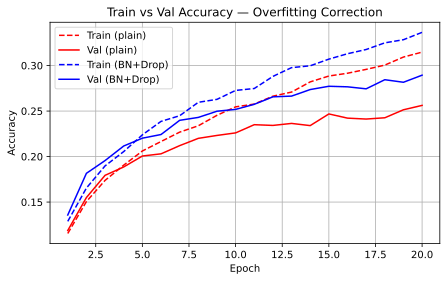

In [54]:
#### Train and Compare results for TwoLayerNetPlus and TwoLayerNet_BNDrop
#### save models and weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# data augmented and normalized
MEAN, STD = (0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)
train_tfms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.CIFAR100(root="./data", train=True, download=True, transform=train_tfms)
test_ds  = datasets.CIFAR100(root="./data", train=False, download=True, transform=test_tfms)

# small validation split
n_val = int(0.1 * len(train_ds))
tr_ds, va_ds = random_split(train_ds, [len(train_ds)-n_val, n_val], generator=torch.Generator().manual_seed(42))

def make_loaders(bs=512, pin=torch.cuda.is_available()):
    tr = DataLoader(tr_ds, batch_size=bs, shuffle=True,  num_workers=0, pin_memory=pin)
    va = DataLoader(va_ds, batch_size=bs, shuffle=False, num_workers=0, pin_memory=pin)
    te = DataLoader(test_ds, batch_size=bs, shuffle=False, num_workers=0, pin_memory=pin)
    return tr, va, te

@torch.no_grad()
def accuracy(loader, model):
    model.eval()
    tot, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        tot += y.size(0)
    return correct / max(1, tot)

def train(model, tr_loader, va_loader, epochs=20, lr=1e-3, wd=1e-4, opt_name="adam", tag="Model"):
    """Train model and save best weights + log."""
    model = model.to(device)
    if opt_name.lower() == "adam":
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    else:
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd, nesterov=True)

    best_state, best_val = None, -1.0
    history = []

    for ep in range(1, epochs+1):
        model.train()
        for x, y in tr_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            opt.step()

        train_acc = accuracy(tr_loader, model)
        val_acc   = accuracy(va_loader, model)
        history.append((ep, train_acc, val_acc))

        if val_acc > best_val:
            best_val, best_state = val_acc, {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"[{tag}] Epoch {ep:02d} | train_acc={train_acc:.3f} | val_acc={val_acc:.3f}")

    model.load_state_dict(best_state)
    print(f"\n[{tag}] Best val_acc={best_val:.3f}\n")

    # saving results 
    out_dir = Path("artifacts/overfitting_experiment")
    out_dir.mkdir(parents=True, exist_ok=True)

    # Save model weights
    weights_path = out_dir / f"{tag}_best_weights.pt"
    torch.save(best_state, weights_path)

    # Save full model 
    full_path = out_dir / f"{tag}_full_model.pth"
    torch.save(model, full_path)

    # Save training log + hyperparams
    df = pd.DataFrame(history, columns=["epoch", "train_acc", "val_acc"])
    df["lr"] = lr
    df["weight_decay"] = wd
    df["optimizer"] = opt_name
    df["epochs_total"] = epochs
    csv_path = out_dir / f"{tag}_training_log.csv"
    df.to_csv(csv_path, index=False)

    print(f"✅ Saved weights: {weights_path}")
    print(f"✅ Saved full model: {full_path}")
    print(f"✅ Saved log: {csv_path}\n")

    return model, history, {"weights": str(weights_path), "model": str(full_path), "log": str(csv_path)}

# run both and compare 
tr_loader, va_loader, te_loader = make_loaders(bs=512)

# First version model (call it plain or plus)
plain, hist_plain, paths_plain = train(
    TwoLayerNetPlus(input_size=3*32*32,hidden1=1024, hidden2=512, hidden3=512, num_classes=100, p=0.3),
    tr_loader, va_loader,
    epochs=20, lr=1e-3, wd=0.0, opt_name="adam", tag="TwoLayerNet_plain"
)

# Second version (BN+Dropout) model
bn_drop, hist_bndrop, paths_bn = train(
    TwoLayerNet_BNDrop(input_size=3*32*32, hidden=1024, num_classes=100, p=0.3),
    tr_loader, va_loader,
    epochs=20, lr=7e-4, wd=1e-4, opt_name="adam", tag="TwoLayerNet_BNDrop"
)

print("Plain  test acc:", accuracy(te_loader, plain))
print("BN+Dp test acc:", accuracy(te_loader, bn_drop))

# plot train and validation accuracy for each model
ep_plain, tr_plain, va_plain = zip(*hist_plain)
ep_bn, tr_bn, va_bn = zip(*hist_bndrop)

plt.figure(figsize=(7,4))
plt.plot(ep_plain, tr_plain, 'r--', label='Train (plain)')
plt.plot(ep_plain, va_plain, 'r', label='Val (plain)')
plt.plot(ep_bn, tr_bn, 'b--', label='Train (BN+Drop)')
plt.plot(ep_bn, va_bn, 'b', label='Val (BN+Drop)')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Val Accuracy — Overfitting Correction")
plt.legend()
plt.grid(True)
plt.show()


___________________

##### Hyperparameter tuning for the new models - where we add 2 extra layers
- we use Optuna for hyperparameter tuning
- we previously trained all defined versions (6) of the two original models (TwoLayerNet and ConvNet), and for tuning, we are using the most successful version for each model, that is: TwoLayerNet_BDR & ConvNetPlus

_________________

In [63]:
#### Hyperparameter tuning with Optuna for TwoLayerNet_BDR & ConvNetPlus 

seed = 42
random.seed(seed); torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()
torch.backends.cudnn.benchmark = True

root = "./data"

NUM_CLASSES = 100
INPUT_SIZE  = 3 * 32 * 32  # CIFAR-100 flattened input

# data transforms 
mean = (0.5071, 0.4867, 0.4408)
std  = (0.2675, 0.2565, 0.2761)

tf_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
tf_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_set = datasets.CIFAR100(root=root, train=False, download=True, transform=tf_test)

### the two versions we tune

class TwoLayerNet_BNDrop(nn.Module):
    def __init__(self, input_size=INPUT_SIZE, hidden=1024, num_classes=NUM_CLASSES, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden), nn.ReLU(inplace=True),

            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(drop),

            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(drop),

            nn.Linear(hidden, num_classes),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x.flatten(1))

class ConvNetPlus(nn.Module):
    def __init__(self, num_classes=100, drop2d=0.2, width_mult=5.0):
        super().__init__()
        c1 = max(6,   int(6   * width_mult))
        c2 = max(16,  int(16  * width_mult))
        c3 = max(120, int(120 * width_mult))
        self.features = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=5, padding=2),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(c1, c2, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(drop2d),

            nn.Conv2d(c2, c3, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c3, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

### validation set
def split_train_val():
    train_full = datasets.CIFAR100(root=root, train=True, download=True, transform=tf_train)
    n_val = int(0.1 * len(train_full))
    return random_split(train_full, [len(train_full)-n_val, n_val], generator=torch.Generator().manual_seed(seed))

def make_loaders(train_set, val_set, batch_size):
    import os as _os
    nw = max(2, (_os.cpu_count() or 4) // 2)
    dl_args = dict(num_workers=nw, pin_memory=pin, persistent_workers=True)
    tr = DataLoader(train_set, batch_size=batch_size, shuffle=True,  **dl_args)
    va = DataLoader(val_set,   batch_size=batch_size, shuffle=False, **dl_args)
    te = DataLoader(test_set,  batch_size=batch_size, shuffle=False, **dl_args)
    return tr, va, te

@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    corr = tot = 0
    for x,y in loader:
        x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        pred = model(x).argmax(1)
        tot += y.size(0); corr += (pred==y).sum().item()
    return corr / max(1, tot)

scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x,y in loader:
        x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / max(1, total)

def train_model(model, train_loader, val_loader, epochs, base_lr, weight_decay, opt_name):
    if opt_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=base_lr, momentum=0.9,
                              weight_decay=weight_decay, nesterov=True)
    else:
        optimizer = optim.Adam(model.parameters(), lr=base_lr, weight_decay=weight_decay)

    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=0.0)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_state, best_val = None, -1.0
    patience, waited = 6, 0

    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_acc = accuracy(model, val_loader)
        scheduler.step()

        if val_acc > best_val:
            best_val, best_state, waited = val_acc, copy.deepcopy(model.state_dict()), 0
        else:
            waited += 1

        lr_now = scheduler.get_last_lr()[0]
        print(f"Epoch {ep:02d}/{epochs} | lr={lr_now:.4f} | loss={tr_loss:.4f} | "
              f"train_acc={tr_acc*100:.2f}% | val_acc={val_acc*100:.2f}%")
        if waited >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_val

#### hyperparameters grid TwoLayerNet
def objective_tw(trial):
    hidden = trial.suggest_categorical("hidden_size",
              [512, 768, 1024, 1536, 2048] if device.type=="cuda" else [256, 512, 768])
    drop   = trial.suggest_float("dropout", 0.2, 0.6, step=0.1)
    lr     = trial.suggest_float("lr", 5e-4, 3e-3, log=True)
    wd     = trial.suggest_float("weight_decay", 1e-5, 5e-4, log=True)
    optn   = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    bs     = trial.suggest_categorical("batch_size", [128, 256])
    epochs = trial.suggest_categorical("epochs", [20, 30])

    train_set, val_set = split_train_val()
    tr, va, _ = make_loaders(train_set, val_set, bs)

    model = TwoLayerNet_BNDrop(hidden=hidden, drop=drop).to(device)
    val_acc = train_model(model, tr, va, epochs=epochs,
                          base_lr=lr, weight_decay=wd, opt_name=optn)
    trial.set_user_attr("hidden_size_effective", hidden)
    return val_acc

#### hyperparameters grid ConvNet
def objective_cnn(trial):
    width  = trial.suggest_categorical("width_mult", [1.0, 1.5, 2.0, 2.5, 3.0])
    drop2d = trial.suggest_float("dropout2d", 0.1, 0.6, step=0.1)
    lr     = trial.suggest_float("lr", 5e-4, 3e-2, log=True)
    wd     = trial.suggest_float("weight_decay", 1e-5, 5e-4, log=True)
    optn   = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    bs     = trial.suggest_categorical("batch_size", [64, 96, 128, 256])
    epochs = trial.suggest_categorical("epochs", [20, 30])

    train_set, val_set = split_train_val()
    tr, va, _ = make_loaders(train_set, val_set, bs)

    model = ConvNetPlus(drop2d=drop2d, width_mult=width).to(device)
    val_acc = train_model(model, tr, va, epochs=epochs,
                          base_lr=lr, weight_decay=wd, opt_name=optn)
    return val_acc

def run_search_and_save(n_trials_tw=10, n_trials_cnn=16, out_dir="./outputs_fast"):
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    # TwoLayerNet
    st_tw = optuna.create_study(direction="maximize", study_name="TwoLayerNet_BNDrop_fast")
    st_tw.optimize(objective_tw, n_trials=n_trials_tw, show_progress_bar=False)
    bt_tw = st_tw.best_trial
    print(f"\n[TwoLayerNet_BNDrop_fast] best val_acc={bt_tw.value*100:.2f}% | params={bt_tw.params} | hidden={bt_tw.user_attrs.get('hidden_size_effective')}")

    # Refit on full train
    tr_full = datasets.CIFAR100(root=root, train=True, download=True, transform=tf_train)
    import os as _os
    nw = max(2, (_os.cpu_count() or 4) // 2)
    tr_loader = DataLoader(tr_full, batch_size=bt_tw.params["batch_size"], shuffle=True,
                           num_workers=nw, pin_memory=pin, persistent_workers=True)
    te_loader = DataLoader(test_set, batch_size=bt_tw.params["batch_size"], shuffle=False,
                           num_workers=nw, pin_memory=pin, persistent_workers=True)

    hidden = bt_tw.user_attrs.get("hidden_size_effective", bt_tw.params.get("hidden_size", 512))
    mdl_tw = TwoLayerNet_BNDrop(hidden=hidden, drop=bt_tw.params["dropout"]).to(device)
    _ = train_model(mdl_tw, tr_loader, tr_loader,
                    epochs=5, base_lr=bt_tw.params["lr"],
                    weight_decay=bt_tw.params["weight_decay"], opt_name=bt_tw.params["optimizer"])
    torch.save(mdl_tw.state_dict(), os.path.join(out_dir, "best_TwoLayerNet_BNDrop_weights.pt"))
    torch.save(mdl_tw,               os.path.join(out_dir, "best_TwoLayerNet_BNDrop_model.pth"))

    # ConvNet
    st_cnn = optuna.create_study(direction="maximize", study_name="ConvNetPlusWide_fast")
    st_cnn.optimize(objective_cnn, n_trials=n_trials_cnn, show_progress_bar=False)
    bt_cnn = st_cnn.best_trial
    print(f"\n[ConvNetPlus] best val_acc={bt_cnn.value*100:.2f}% | params={bt_cnn.params}")

    tr_loader = DataLoader(tr_full, batch_size=bt_cnn.params["batch_size"], shuffle=True,
                           num_workers=nw, pin_memory=pin, persistent_workers=True)
    te_loader = DataLoader(test_set, batch_size=bt_cnn.params["batch_size"], shuffle=False,
                           num_workers=nw, pin_memory=pin, persistent_workers=True)

    mdl_cnn = ConvNetPlus(drop2d=bt_cnn.params["dropout2d"], width_mult=bt_cnn.params["width_mult"]).to(device)
    _ = train_model(mdl_cnn, tr_loader, tr_loader,
                    epochs=5, base_lr=bt_cnn.params["lr"],
                    weight_decay=bt_cnn.params["weight_decay"], opt_name=bt_cnn.params["optimizer"])
    torch.save(mdl_cnn.state_dict(), os.path.join(out_dir, "best_ConvNetPlus_weights.pt"))
    torch.save(mdl_cnn,               os.path.join(out_dir, "best_ConvNetPlus_model.pth"))

    rows = [
        {"model":"TwoLayerNet_BNDrop", "best_val_acc":bt_tw.value,
         "hidden_size_effective":bt_tw.user_attrs.get("hidden_size_effective"), **bt_tw.params},
        {"model":"ConvNetPlusW", "best_val_acc":bt_cnn.value, **bt_cnn.params},
    ]
    pd.DataFrame(rows).to_csv(os.path.join(out_dir, "best_hyperparameters.csv"), index=False)
    print(f"\nSaved to {out_dir}")

if __name__ == "__main__":
    run_search_and_save()


Files already downloaded and verified


C:\Users\didi_\AppData\Local\Temp\ipykernel_18796\1973918633.py:123: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.

[I 2025-10-24 20:34:57,528] A new study created in memory with name: TwoLayerNet_BNDrop_fast


Files already downloaded and verified


C:\Users\didi_\AppData\Local\Temp\ipykernel_18796\1973918633.py:131: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



Epoch 01/20 | lr=0.0008 | loss=4.7024 | train_acc=1.61% | val_acc=4.88%
Epoch 02/20 | lr=0.0008 | loss=4.5591 | train_acc=3.12% | val_acc=6.42%
Epoch 03/20 | lr=0.0007 | loss=4.4503 | train_acc=4.14% | val_acc=7.06%
Epoch 04/20 | lr=0.0007 | loss=4.3773 | train_acc=4.98% | val_acc=8.68%
Epoch 05/20 | lr=0.0007 | loss=4.3199 | train_acc=5.70% | val_acc=9.42%
Epoch 06/20 | lr=0.0006 | loss=4.2767 | train_acc=6.33% | val_acc=9.98%
Epoch 07/20 | lr=0.0006 | loss=4.2404 | train_acc=6.84% | val_acc=10.54%
Epoch 08/20 | lr=0.0005 | loss=4.2162 | train_acc=7.14% | val_acc=11.20%
Epoch 09/20 | lr=0.0004 | loss=4.1897 | train_acc=7.60% | val_acc=11.64%
Epoch 10/20 | lr=0.0004 | loss=4.1698 | train_acc=7.82% | val_acc=11.70%
Epoch 11/20 | lr=0.0003 | loss=4.1504 | train_acc=8.18% | val_acc=11.58%
Epoch 12/20 | lr=0.0003 | loss=4.1412 | train_acc=8.50% | val_acc=12.20%
Epoch 13/20 | lr=0.0002 | loss=4.1289 | train_acc=8.60% | val_acc=12.46%
Epoch 14/20 | lr=0.0002 | loss=4.1209 | train_acc=8.81% |

...

Files already downloaded and verified
Epoch 01/20 | lr=0.0037 | loss=4.4681 | train_acc=2.86% | val_acc=5.82%
Epoch 02/20 | lr=0.0037 | loss=4.2873 | train_acc=5.80% | val_acc=9.14%
Epoch 03/20 | lr=0.0035 | loss=4.1778 | train_acc=7.90% | val_acc=10.04%
Epoch 04/20 | lr=0.0034 | loss=4.1005 | train_acc=9.20% | val_acc=12.20%
Epoch 05/20 | lr=0.0032 | loss=4.0184 | train_acc=10.96% | val_acc=13.66%
Epoch 06/20 | lr=0.0030 | loss=3.9485 | train_acc=12.21% | val_acc=15.80%
Epoch 07/20 | lr=0.0027 | loss=3.9003 | train_acc=13.40% | val_acc=16.46%
Epoch 08/20 | lr=0.0025 | loss=3.8631 | train_acc=14.39% | val_acc=17.14%
Epoch 09/20 | lr=0.0022 | loss=3.8248 | train_acc=15.26% | val_acc=17.84%
Epoch 10/20 | lr=0.0019 | loss=3.7955 | train_acc=15.84% | val_acc=18.96%
Epoch 11/20 | lr=0.0016 | loss=3.7654 | train_acc=16.63% | val_acc=19.20%
Epoch 12/20 | lr=0.0013 | loss=3.7405 | train_acc=17.18% | val_acc=20.24%
Epoch 13/20 | lr=0.0010 | loss=3.7181 | train_acc=17.70% | val_acc=20.18%
Epoch 

[I 2025-10-24 21:55:30,873] Trial 14 finished with value: 0.2244 and parameters: {'width_mult': 2.5, 'dropout2d': 0.2, 'lr': 0.003745401906995055, 'weight_decay': 8.881651423825534e-05, 'optimizer': 'adam', 'batch_size': 64, 'epochs': 20}. Best is trial 6 with value: 0.4536.


Files already downloaded and verified
Epoch 01/20 | lr=0.0026 | loss=4.5240 | train_acc=2.27% | val_acc=4.46%
Epoch 02/20 | lr=0.0026 | loss=4.3036 | train_acc=5.10% | val_acc=6.76%
Epoch 03/20 | lr=0.0025 | loss=4.1942 | train_acc=7.29% | val_acc=8.96%
Epoch 04/20 | lr=0.0024 | loss=4.0910 | train_acc=8.96% | val_acc=10.84%
Epoch 05/20 | lr=0.0023 | loss=4.0019 | train_acc=10.47% | val_acc=12.58%
Epoch 06/20 | lr=0.0021 | loss=3.9321 | train_acc=12.19% | val_acc=13.22%
Epoch 07/20 | lr=0.0019 | loss=3.8759 | train_acc=13.21% | val_acc=15.98%
Epoch 08/20 | lr=0.0017 | loss=3.8299 | train_acc=14.48% | val_acc=17.40%
Epoch 09/20 | lr=0.0015 | loss=3.7847 | train_acc=15.56% | val_acc=18.12%
Epoch 10/20 | lr=0.0013 | loss=3.7502 | train_acc=16.13% | val_acc=18.78%
Epoch 11/20 | lr=0.0011 | loss=3.7122 | train_acc=17.16% | val_acc=19.76%
Epoch 12/20 | lr=0.0009 | loss=3.6781 | train_acc=17.88% | val_acc=20.16%
Epoch 13/20 | lr=0.0007 | loss=3.6494 | train_acc=18.82% | val_acc=20.62%
Epoch 1

[I 2025-10-24 21:58:40,901] Trial 15 finished with value: 0.2334 and parameters: {'width_mult': 3.0, 'dropout2d': 0.1, 'lr': 0.002643339985891512, 'weight_decay': 1.0967619863846714e-05, 'optimizer': 'sgd', 'batch_size': 96, 'epochs': 20}. Best is trial 6 with value: 0.4536.



[ConvNetPlus] best val_acc=45.36% | params={'width_mult': 2.5, 'dropout2d': 0.2, 'lr': 0.029778107023820576, 'weight_decay': 4.556776304755489e-05, 'optimizer': 'sgd', 'batch_size': 64, 'epochs': 20}
Epoch 01/5 | lr=0.0269 | loss=4.2394 | train_acc=6.10% | val_acc=10.12%
Epoch 02/5 | lr=0.0195 | loss=3.9029 | train_acc=12.43% | val_acc=16.87%
Epoch 03/5 | lr=0.0103 | loss=3.6547 | train_acc=17.97% | val_acc=22.24%
Epoch 04/5 | lr=0.0028 | loss=3.4791 | train_acc=22.21% | val_acc=27.10%
Epoch 05/5 | lr=0.0000 | loss=3.3574 | train_acc=25.38% | val_acc=29.45%

Saved to ./outputs_fast


_________________________

#### Run longer after optuna - ConvNetPlus
- use optimal hyperparameter values
    - 'width_mult': 2.5,
    - 'dropout2d': 0.2,
    - 'lr': 0.029778107023820576,
    - 'weight_decay': 4.556776304755489e-05,
    - 'optimizer': 'sgd',
    - 'batch_size': 64, 'epochs': 20}
_______________


In [76]:
# params from search:
# {'width_mult': 2.5, 'dropout2d': 0.2, 'lr': 0.029778107023820576,
#  'weight_decay': 4.556776304755489e-05, 'optimizer': 'sgd',
#  'batch_size': 64, 'epochs': 20}

seed = 42
random.seed(seed); torch.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()
torch.backends.cudnn.benchmark = True

root = "./data"
out_dir = "./outputs_simple_cnnrefit_long"
Path(out_dir).mkdir(parents=True, exist_ok=True)

# ------- data -------
mean = (0.5071, 0.4867, 0.4408)
std  = (0.2675, 0.2565, 0.2761)

tf_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3), inplace=True),
])
tf_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_set = datasets.CIFAR100(root=root, train=False, download=True, transform=tf_test)

def split_train_val(val_frac=0.1):
    full = datasets.CIFAR100(root=root, train=True, download=True, transform=tf_train)
    n_val = int(val_frac * len(full))
    return random_split(full, [len(full)-n_val, n_val],
                        generator=torch.Generator().manual_seed(seed))

def make_loaders(train_set, val_set, batch_size):
    nw = max(2, (os.cpu_count() or 4)//2)
    args = dict(num_workers=nw, pin_memory=pin, persistent_workers=True)
    tr = DataLoader(train_set, batch_size=batch_size, shuffle=True,  **args)
    va = DataLoader(val_set,   batch_size=batch_size, shuffle=False, **args)
    te = DataLoader(test_set,  batch_size=batch_size, shuffle=False, **args)
    return tr, va, te

@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    corr = tot = 0
    for x,y in loader:
        x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        pred = model(x).argmax(1)
        corr += (pred == y).sum().item(); tot += y.size(0)
    return corr / max(1, tot)

# model 
class ConvNetPlus(nn.Module):
    def __init__(self, num_classes=100, drop2d=0.2, width_mult=2.5):
        super().__init__()
        c1 = max(6,   int(6   * width_mult))
        c2 = max(16,  int(16  * width_mult))
        c3 = max(120, int(120 * width_mult))
        self.features = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=5, padding=2),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 32->16

            nn.Conv2d(c1, c2, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 16->8
            nn.Dropout2d(drop2d),

            nn.Conv2d(c2, c3, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1),  # GAP
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c3, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# training 
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x,y in loader:
        x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss/total, correct/max(1,total)

def train_model(model, train_loader, val_loader, test_loader,
                epochs=20, base_lr=0.03, weight_decay=5e-5):
    optimizer = optim.SGD(model.parameters(),
                          lr=base_lr,
                          momentum=0.9,
                          nesterov=True,
                          weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=0.0)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    hist_train_acc = []
    hist_val_acc   = []
    hist_test_acc  = []

    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_acc  = accuracy(model, val_loader)
        test_acc = accuracy(model, test_loader)
        scheduler.step()

        hist_train_acc.append(tr_acc * 100.0)
        hist_val_acc.append(val_acc * 100.0)
        hist_test_acc.append(test_acc * 100.0)

        print(f"Epoch {ep:02d}/{epochs} | lr={scheduler.get_last_lr()[0]:.4f} "
              f"| loss={tr_loss:.4f} | train_acc={tr_acc*100:.2f}% "
              f"| val_acc={val_acc*100:.2f}% | test_acc={test_acc*100:.2f}%")

    return {
        "train_acc": hist_train_acc,
        "val_acc":   hist_val_acc,
        "test_acc":  hist_test_acc,
    }

# run for best hyperparameters
if __name__ == "__main__":
    # injected best hyperparams from Optuna
    width_mult    = 2.5
    drop2d        = 0.2
    base_lr       = 0.029778107023820576
    weight_decay  = 4.556776304755489e-05
    batch_size    = 64
    epochs        = 150

    train_set, val_set = split_train_val(val_frac=0.1)
    tr, va, te = make_loaders(train_set, val_set, batch_size)

    model = ConvNetPlus(drop2d=drop2d, width_mult=width_mult).to(device)

    hist = train_model(
        model,
        tr, va, te,
        epochs=epochs,
        base_lr=base_lr,
        weight_decay=weight_decay,
    )

    # final test eval (after full training)
    test_acc = accuracy(model, te)
    print(f"\nFinal test acc: {test_acc*100:.2f}%")

    # save weights and full model
    torch.save(model.state_dict(), os.path.join(out_dir, "ConvNetPlus_refit_weights.pt"))
    torch.save(model,               os.path.join(out_dir, "ConvNetPlus_refit_model.pth"))

    # save summary row
    pd.DataFrame([{
        "model":"ConvNetPlus_refit",
        "final_test_acc":float(test_acc),
        "width_mult":width_mult,
        "dropout2d":drop2d,
        "batch_size":batch_size,
        "epochs":epochs,
        "base_lr":base_lr,
        "weight_decay":weight_decay,
        "optimizer":"sgd"
    }]).to_csv(os.path.join(out_dir, "run_summary.csv"), index=False)

    # plot accuracy curves and save figure as SVG
    plt.figure(figsize=(6,4))
    plt.plot(hist["train_acc"], label="Train acc")
    plt.plot(hist["val_acc"],   label="Val acc")
    plt.plot(hist["test_acc"],  label="Test acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("ConvNetPlus accuracy curves (refit)")
    plt.grid(True)
    plt.legend()
    svg_path = os.path.join(out_dir, "acc_curves_refit.svg")
    plt.savefig(svg_path, format="svg", bbox_inches="tight")
    plt.close()

    print(f"\nSaved weights, model, plot to {out_dir}")


Files already downloaded and verified


C:\Users\didi_\AppData\Local\Temp\ipykernel_18796\19203003.py:102: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



Files already downloaded and verified


C:\Users\didi_\AppData\Local\Temp\ipykernel_18796\19203003.py:110: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



Epoch 01/150 | lr=0.0298 | loss=4.2567 | train_acc=5.76% | val_acc=9.12% | test_acc=9.34%
Epoch 02/150 | lr=0.0298 | loss=3.9592 | train_acc=11.02% | val_acc=14.14% | test_acc=14.32%
Epoch 03/150 | lr=0.0297 | loss=3.7479 | train_acc=16.19% | val_acc=19.02% | test_acc=18.75%
Epoch 04/150 | lr=0.0297 | loss=3.5905 | train_acc=19.57% | val_acc=23.98% | test_acc=24.59%
Epoch 05/150 | lr=0.0297 | loss=3.4654 | train_acc=22.80% | val_acc=24.82% | test_acc=25.16%
Epoch 06/150 | lr=0.0297 | loss=3.3637 | train_acc=25.23% | val_acc=29.62% | test_acc=30.71%
Epoch 07/150 | lr=0.0296 | loss=3.2797 | train_acc=27.50% | val_acc=29.86% | test_acc=32.16%
Epoch 08/150 | lr=0.0296 | loss=3.2024 | train_acc=29.27% | val_acc=33.76% | test_acc=35.62%
Epoch 09/150 | lr=0.0295 | loss=3.1482 | train_acc=30.70% | val_acc=34.04% | test_acc=36.62%
Epoch 10/150 | lr=0.0295 | loss=3.0904 | train_acc=32.21% | val_acc=33.90% | test_acc=36.51%
Epoch 11/150 | lr=0.0294 | loss=3.0456 | train_acc=33.28% | val_acc=35.38

________________
- Some new experiments for ConvNetPlus (different hyperparameter values)
________________


In [70]:
### ConvNetPlus (with padding + GAP) and with Early Stopping (no Optuna) 
### differnet choice for hyperparameters

seed = 42
random.seed(seed); torch.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()
torch.backends.cudnn.benchmark = True

root = "./data"
out_dir = "./outputs_simple65_earlystop"
Path(out_dir).mkdir(parents=True, exist_ok=True)

### data transform
mean = (0.5071, 0.4867, 0.4408)
std  = (0.2675, 0.2565, 0.2761)

tf_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    # simple, effective regularization
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3), inplace=True),
])
tf_test = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])

test_set = datasets.CIFAR100(root=root, train=False, download=True, transform=tf_test)

def split_train_val(val_frac=0.1):
    train_full = datasets.CIFAR100(root=root, train=True, download=True, transform=tf_train)
    n_val = int(val_frac * len(train_full))
    return random_split(train_full, [len(train_full)-n_val, n_val],
                        generator=torch.Generator().manual_seed(seed))

def make_loaders(train_set, val_set, batch_size):
    nw = max(2, (os.cpu_count() or 4)//2)
    args = dict(num_workers=nw, pin_memory=pin, persistent_workers=True)
    tr = DataLoader(train_set, batch_size=batch_size, shuffle=True,  **args)
    va = DataLoader(val_set,   batch_size=batch_size, shuffle=False, **args)
    te = DataLoader(test_set,  batch_size=batch_size, shuffle=False, **args)
    return tr, va, te

@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    corr = tot = 0
    for x,y in loader:
        x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        pred = model(x).argmax(1)
        corr += (pred == y).sum().item(); tot += y.size(0)
    return corr / max(1, tot)

# model 
class ConvNetPlus(nn.Module):
    """
    +2 layers only:
      (+1) BatchNorm2d after Conv1
      (+2) Dropout2d after Pool2
    Swaps: ReLU for Tanh, AvgPool->MaxPool, padding=2 on 5x5, GAP head.
    """
    def __init__(self, num_classes=100, drop2d=0.2, width_mult=5.0):
        super().__init__()
        c1 = max(6,   int(6   * width_mult))
        c2 = max(16,  int(16  * width_mult))
        c3 = max(120, int(120 * width_mult))
        self.features = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=5, padding=2),  # keep 32x32
            nn.BatchNorm2d(c1),                          # (+1)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 32->16

            nn.Conv2d(c1, c2, kernel_size=5, padding=2), # 16->16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 16->8
            nn.Dropout2d(drop2d),                        # (+2)

            nn.Conv2d(c2, c3, kernel_size=5, padding=2), # 8->8
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1),                     # GAP
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c3, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# training 
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x,y in loader:
        x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss/total, correct/max(1,total)

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=100,
    base_lr=0.1,
    weight_decay=5e-4,
    early_stop_patience=15,   # stop if no val_acc improvement after N epochs
    early_stop_delta=0.0      # minimum improvement in val_acc to reset patience
):
    optimizer = optim.SGD(model.parameters(), lr=base_lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=0.0)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_val, best_state, best_epoch = -1.0, None, -1
    epochs_since_improve = 0

    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_acc = accuracy(model, val_loader)
        scheduler.step()

        improved = (val_acc - best_val) > early_stop_delta
        if improved:
            best_val = val_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = ep
            epochs_since_improve = 0
            print(f"  ↳ New best val_acc: {best_val*100:.2f}% (epoch {ep})")
        else:
            epochs_since_improve += 1

        print(f"Epoch {ep:03d}/{epochs} | lr={scheduler.get_last_lr()[0]:.4f} "
              f"| loss={tr_loss:.4f} | train_acc={tr_acc*100:.2f}% | val_acc={val_acc*100:.2f}% "
              f"| no_improve={epochs_since_improve}/{early_stop_patience}")

        if epochs_since_improve >= early_stop_patience:
            print(f"Early stopping triggered (no improvement > {early_stop_delta:.4f} for {early_stop_patience} epochs).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best weights from epoch {best_epoch} (val_acc={best_val*100:.2f}%).")
    return best_val

# run 
if __name__ == "__main__":
    # Strong, simple defaults aimed at >65%
    width_mult = 5.0    # try 6.0 if VRAM allows
    drop2d     = 0.2
    batch_size = 128
    epochs     = 100
    base_lr    = 0.1
    weight_decay = 5e-4
    early_stop_patience = 15   # feel free to set 20 if training longer
    early_stop_delta    = 0.001  # require +0.1% absolute improvement to reset patience

    train_set, val_set = split_train_val(val_frac=0.1)
    tr, va, te = make_loaders(train_set, val_set, batch_size)
    model = ConvNetPlus(drop2d=drop2d, width_mult=width_mult).to(device)

    best_val = train_model(
        model, tr, va,
        epochs=epochs,
        base_lr=base_lr,
        weight_decay=weight_decay,
        early_stop_patience=early_stop_patience,
        early_stop_delta=early_stop_delta
    )
    print(f"\nBest val_acc: {best_val*100:.2f}%")

    # final test eval (on best weights)
    test_acc = accuracy(model, te)
    print(f"Test acc: {test_acc*100:.2f}%")

    # save artifacts + config
    torch.save(model.state_dict(), os.path.join(out_dir, "ConvNetPlus_weights.pt"))
    torch.save(model,               os.path.join(out_dir, "ConvNetPlus_model.pth"))
    pd.DataFrame([{
        "model":"ConvNetPlus_simple_earlystop",
        "best_val_acc":float(best_val),
        "test_acc":float(test_acc),
        "width_mult":width_mult,
        "dropout2d":drop2d,
        "batch_size":batch_size,
        "epochs":epochs,
        "base_lr":base_lr,
        "weight_decay":weight_decay,
        "early_stop_patience":early_stop_patience,
        "early_stop_delta":early_stop_delta
    }]).to_csv(os.path.join(out_dir, "run_summary.csv"), index=False)
    print(f"\nSaved to {out_dir}")


Files already downloaded and verified


C:\Users\didi_\AppData\Local\Temp\ipykernel_18796\1124307961.py:105: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



Files already downloaded and verified


C:\Users\didi_\AppData\Local\Temp\ipykernel_18796\1124307961.py:113: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



  ↳ New best val_acc: 11.84% (epoch 1)
Epoch 001/100 | lr=0.1000 | loss=4.2190 | train_acc=6.40% | val_acc=11.84% | no_improve=0/15
  ↳ New best val_acc: 18.24% (epoch 2)
Epoch 002/100 | lr=0.0999 | loss=3.8489 | train_acc=13.58% | val_acc=18.24% | no_improve=0/15
  ↳ New best val_acc: 23.06% (epoch 3)
Epoch 003/100 | lr=0.0998 | loss=3.6172 | train_acc=18.78% | val_acc=23.06% | no_improve=0/15
  ↳ New best val_acc: 27.80% (epoch 4)
Epoch 004/100 | lr=0.0996 | loss=3.4430 | train_acc=23.08% | val_acc=27.80% | no_improve=0/15
  ↳ New best val_acc: 29.84% (epoch 5)
Epoch 005/100 | lr=0.0994 | loss=3.2974 | train_acc=26.50% | val_acc=29.84% | no_improve=0/15
  ↳ New best val_acc: 33.08% (epoch 6)
Epoch 006/100 | lr=0.0991 | loss=3.1966 | train_acc=28.99% | val_acc=33.08% | no_improve=0/15
  ↳ New best val_acc: 34.36% (epoch 7)
Epoch 007/100 | lr=0.0988 | loss=3.1108 | train_acc=31.46% | val_acc=34.36% | no_improve=0/15
  ↳ New best val_acc: 36.20% (epoch 8)
Epoch 008/100 | lr=0.0984 | los

In [73]:
################## corrected version of the above cell ########################
#### ConvNetPlus (padding + GAP), wider + longer training 

seed = 42
random.seed(seed); torch.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # conv autotune

root = "./data"
out_dir = "./outputs_simple65_cleanval"
Path(out_dir).mkdir(parents=True, exist_ok=True)

# -------------------- data --------------------
mean = (0.5071, 0.4867, 0.4408)
std  = (0.2675, 0.2565, 0.2761)

# Augmented training transform (stochastic)
tf_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3), inplace=True),
])

# Clean/eval transform (deterministic) — used for validation & test
tf_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Fixed test set (clean)
test_set = datasets.CIFAR100(root=root, train=False, download=True, transform=tf_eval)

def split_train_val(val_frac=0.1):
    """
    Build an augmented training dataset, then split indices for train/val subsets.
    Both subsets initially point to the same augmented dataset, but we'll
    rebuild CLEAN views (tf_eval) using these exact indices for evaluation.
    """
    train_full = datasets.CIFAR100(root=root, train=True, download=True, transform=tf_train)
    n_val = int(val_frac * len(train_full))
    train_set, val_set = random_split(
        train_full,
        [len(train_full) - n_val, n_val],
        generator=torch.Generator().manual_seed(seed)
    )
    return train_set, val_set

def make_clean_subset(original_subset, clean_transform):
    """
    Create a Subset sharing the SAME indices as `original_subset`,
    but sourced from a base dataset that uses `clean_transform`.
    """
    base_clean = datasets.CIFAR100(root=root, train=True, download=True, transform=clean_transform)
    return Subset(base_clean, original_subset.indices)

def make_loaders(train_set, val_set, batch_size):
    """
    Returns:
      - tr: augmented train loader (used for optimization & 'noisy' train acc)
      - va_clean: CLEAN val loader (no augmentation) on same val indices
      - te: CLEAN test loader
      - tr_clean: CLEAN train loader (optional — fair train acc in eval mode)
    """
    nw = max(2, (os.cpu_count() or 4)//2)
    dl_args = dict(num_workers=nw, pin_memory=pin, persistent_workers=True)

    # Augmented train loader
    tr = DataLoader(train_set, batch_size=batch_size, shuffle=True, **dl_args)

    # CLEAN views for fair evaluation
    val_clean_subset = make_clean_subset(val_set, tf_eval)
    va_clean = DataLoader(val_clean_subset, batch_size=batch_size, shuffle=False, **dl_args)

    train_clean_subset = make_clean_subset(train_set, tf_eval)
    tr_clean = DataLoader(train_clean_subset, batch_size=batch_size, shuffle=False, **dl_args)

    # Test loader (already clean)
    te = DataLoader(test_set, batch_size=batch_size, shuffle=False, **dl_args)
    return tr, va_clean, te, tr_clean

@torch.no_grad()
def accuracy(model, loader):
    """
    Clean accuracy: runs in eval(), no gradient, on whatever transform the `loader` uses.
    Use this on CLEAN loaders (tf_eval) for fair comparison across splits.
    """
    model.eval()
    corr = tot = 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=pin), y.to(device, non_blocking=pin)
        pred = model(x).argmax(1)
        corr += (pred == y).sum().item()
        tot  += y.size(0)
    return corr / max(1, tot)

# -------------------- model (ONLY +2 layers vs baseline) --------------------
class ConvNetPlus(nn.Module):
    """
    +2 layers only:
      (+1) BatchNorm2d after Conv1
      (+2) Dropout2d after Pool2
    Swaps: ReLU for Tanh, MaxPool for AvgPool, padding=2 on 5x5, GAP head.
    """
    def __init__(self, num_classes=100, drop2d=0.2, width_mult=5.0):
        super().__init__()
        c1 = max(6,   int(6   * width_mult))
        c2 = max(16,  int(16  * width_mult))
        c3 = max(120, int(120 * width_mult))

        self.features = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=5, padding=2),  # keep 32x32
            nn.BatchNorm2d(c1),                          # (+1)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 32 -> 16

            nn.Conv2d(c1, c2, kernel_size=5, padding=2), # 16 -> 16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 16 -> 8
            nn.Dropout2d(drop2d),                        # (+2)

            nn.Conv2d(c2, c3, kernel_size=5, padding=2), # 8 -> 8
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1),                     # GAP
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c3, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# -------------------- training --------------------
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def train_one_epoch(model, loader, criterion, optimizer):
    """
    One epoch of training on AUGMENTED batches in train() mode.
    Returns 'noisy' train acc (useful for optimization signals),
    not directly comparable to clean val/test accuracy.
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=pin), y.to(device, non_blocking=pin)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / max(1, total)

def train_model(
    model,
    train_loader,          # augmented train loader
    val_loader_clean,      # CLEAN val loader (no aug)
    train_loader_clean,    # CLEAN train loader (no aug) for fair train acc
    epochs=150,
    base_lr=0.1,
    weight_decay=5e-4
):
    optimizer = optim.SGD(model.parameters(), lr=base_lr, momentum=0.9,
                          nesterov=True, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=0.0)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_val, best_state = -1.0, None
    patience, waited = 15, 0

    for ep in range(1, epochs + 1):
        # Train on augmented data (noisy train acc)
        tr_loss, tr_acc_noisy = train_one_epoch(model, train_loader, criterion, optimizer)

        # Clean metrics in eval() for fair comparison
        tr_acc_clean = accuracy(model, train_loader_clean)
        val_acc      = accuracy(model, val_loader_clean)

        scheduler.step()

        if val_acc > best_val:
            best_val, best_state, waited = val_acc, copy.deepcopy(model.state_dict()), 0
            print(f"  ↳ New best val_acc (clean): {best_val*100:.2f}% at epoch {ep}")
        else:
            waited += 1

        print(f"Epoch {ep:03d}/{epochs} | lr={scheduler.get_last_lr()[0]:.4f} "
              f"| loss={tr_loss:.4f} | train_acc(noisy)={tr_acc_noisy*100:.2f}% "
              f"| train_acc(clean)={tr_acc_clean*100:.2f}% | val_acc(clean)={val_acc*100:.2f}%")

        if waited >= patience:
            print("Early stopping triggered (no validation improvement).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_val

# -------------------- run --------------------
if __name__ == "__main__":
    # Strong, simple defaults
    width_mult = 5.0    # try 6.0 if VRAM allows
    drop2d     = 0.2
    batch_size = 128
    epochs     = 100
    base_lr    = 0.1
    weight_decay = 5e-4

    # Split & loaders
    train_set, val_set = split_train_val(val_frac=0.1)
    tr, va_clean, te, tr_clean = make_loaders(train_set, val_set, batch_size)

    # Model
    model = ConvNetPlus(drop2d=drop2d, width_mult=width_mult).to(device)

    # Train (model selection on CLEAN val)
    best_val = train_model(
        model,
        train_loader=tr,
        val_loader_clean=va_clean,
        train_loader_clean=tr_clean,
        epochs=epochs,
        base_lr=base_lr,
        weight_decay=weight_decay
    )
    print(f"\nBest val_acc (clean): {best_val*100:.2f}%")

    # Final test eval (clean)
    test_acc = accuracy(model, te)
    print(f"Test acc (clean): {test_acc*100:.2f}%")

    # Save artifacts + config
    torch.save(model.state_dict(), os.path.join(out_dir, "ConvNetPlus_weights.pt"))
    torch.save(model,               os.path.join(out_dir, "ConvNetPlus_model.pth"))
    pd.DataFrame([{
        "model":"ConvNetPlus_simple_cleanval",
        "best_val_acc_clean": float(best_val),
        "test_acc_clean": float(test_acc),
        "width_mult": width_mult,
        "dropout2d": drop2d,
        "batch_size": batch_size,
        "epochs": epochs,
        "base_lr": base_lr,
        "weight_decay": weight_decay,
        "device": str(device),
    }]).to_csv(os.path.join(out_dir, "run_summary.csv"), index=False)

    print(f"\nSaved to {out_dir}")


Files already downloaded and verified


C:\Users\didi_\AppData\Local\Temp\ipykernel_18796\1394358644.py:154: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


C:\Users\didi_\AppData\Local\Temp\ipykernel_18796\1394358644.py:167: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



  ↳ New best val_acc (clean): 12.58% at epoch 1
Epoch 001/100 | lr=0.1000 | loss=4.2190 | train_acc(noisy)=6.40% | train_acc(clean)=11.93% | val_acc(clean)=12.58%
  ↳ New best val_acc (clean): 19.24% at epoch 2
Epoch 002/100 | lr=0.0999 | loss=3.8480 | train_acc(noisy)=13.71% | train_acc(clean)=18.73% | val_acc(clean)=19.24%
  ↳ New best val_acc (clean): 24.22% at epoch 3
Epoch 003/100 | lr=0.0998 | loss=3.6180 | train_acc(noisy)=18.86% | train_acc(clean)=24.94% | val_acc(clean)=24.22%
  ↳ New best val_acc (clean): 28.50% at epoch 4
Epoch 004/100 | lr=0.0996 | loss=3.4359 | train_acc(noisy)=23.21% | train_acc(clean)=29.48% | val_acc(clean)=28.50%
  ↳ New best val_acc (clean): 30.28% at epoch 5
Epoch 005/100 | lr=0.0994 | loss=3.2974 | train_acc(noisy)=26.72% | train_acc(clean)=31.97% | val_acc(clean)=30.28%
  ↳ New best val_acc (clean): 34.94% at epoch 6
Epoch 006/100 | lr=0.0991 | loss=3.1890 | train_acc(noisy)=29.69% | train_acc(clean)=36.54% | val_acc(clean)=34.94%
Epoch 007/100 | l

In [74]:
# ConvNetPlus (clean validation) (no Optuna) 

################################### BEST RESULTS here #########################

seed = 42
random.seed(seed); torch.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

root = "./data"
out_dir = "./outputs_convnetplus_simple65"
Path(out_dir).mkdir(parents=True, exist_ok=True)

# -------------------- data --------------------
mean = (0.5071, 0.4867, 0.4408)
std  = (0.2675, 0.2565, 0.2761)

# Train 
tf_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    AutoAugment(AutoAugmentPolicy.CIFAR10),  # single line, big gain
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3), inplace=True),
])

# Eval (clean)
tf_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_set = datasets.CIFAR100(root=root, train=False, download=True, transform=tf_eval)

def split_train_val(val_frac=0.1):
    train_full = datasets.CIFAR100(root=root, train=True, download=True, transform=tf_train)
    n_val = int(val_frac * len(train_full))
    train_set, val_set = random_split(
        train_full, [len(train_full)-n_val, n_val],
        generator=torch.Generator().manual_seed(seed)
    )
    return train_set, val_set

def clean_view(subset, transform=tf_eval):
    base = datasets.CIFAR100(root=root, train=True, download=True, transform=transform)
    return Subset(base, subset.indices)

def make_loaders(train_set, val_set, batch_size):
    nw = max(2, (os.cpu_count() or 4)//2)
    args = dict(num_workers=nw, pin_memory=pin, persistent_workers=True)
    tr = DataLoader(train_set, batch_size=batch_size, shuffle=True,  **args)              # augmented
    va = DataLoader(clean_view(val_set), batch_size=batch_size, shuffle=False, **args)    # clean
    te = DataLoader(test_set,          batch_size=batch_size, shuffle=False, **args)      # clean
    return tr, va, te

@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    corr = tot = 0
    for x,y in loader:
        x,y = x.to(device, non_blocking=pin), y.to(device, non_blocking=pin)
        pred = model(x).argmax(1)
        corr += (pred == y).sum().item(); tot += y.size(0)
    return corr / max(1, tot)

# model 
class ConvNetPlus(nn.Module):
    """
    +2 new layers total:
      (+1) BatchNorm2d after Conv1
      (+2) Dropout2d after Pool2
    Swaps (not counted as new layers): ReLU for Tanh, MaxPool for AvgPool, padding=2, GAP head.
    """
    def __init__(self, num_classes=100, drop2d=0.2, width_mult=6.0):
        super().__init__()
        c1 = max(6,   int(6   * width_mult))
        c2 = max(16,  int(16  * width_mult))
        c3 = max(120, int(120 * width_mult))
        self.features = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=5, padding=2),  # 32x32
            nn.BatchNorm2d(c1),                          # (+1)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),                           # 32->16

            nn.Conv2d(c1, c2, kernel_size=5, padding=2), # 16->16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),                           # 16->8
            nn.Dropout2d(drop2d),                        # (+2)

            nn.Conv2d(c2, c3, kernel_size=5, padding=2), # 8->8
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1),                     # GAP
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c3, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

#  training 
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def train_one_epoch(model, loader, criterion, optimizer):
    """Train on augmented data; returns 'noisy' training accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x,y in loader:
        x,y = x.to(device, non_blocking=pin), y.to(device, non_blocking=pin)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total   += y.size(0)
    return total_loss/total, correct/max(1,total)

def train_model(model, tr, va, epochs=200, base_lr=0.1, weight_decay=5e-4,
                early_stop_patience=25, label_smoothing=0.1):
    optimizer = optim.SGD(model.parameters(), lr=base_lr, momentum=0.9,
                          nesterov=True, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=0.0)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    best_val, best_state, waited = -1.0, None, 0
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, tr, criterion, optimizer)
        val_acc = accuracy(model, va)  # clean val
        scheduler.step()

        if val_acc > best_val:
            best_val, best_state, waited = val_acc, copy.deepcopy(model.state_dict()), 0
            print(f"  ↳ New best val_acc: {best_val*100:.2f}% (epoch {ep})")
        else:
            waited += 1

        print(f"Epoch {ep:03d}/{epochs} | lr={scheduler.get_last_lr()[0]:.4f} "
              f"| loss={tr_loss:.4f} | train_acc(noisy)={tr_acc*100:.2f}% | val_acc(clean)={val_acc*100:.2f}%")

        if waited >= early_stop_patience:
            print("Early stopping: no val improvement.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_val

# run 
if __name__ == "__main__":
    # Simple, strong defaults to push >65%
    width_mult = 6.0     # try 7.0 if VRAM allows
    drop2d     = 0.2
    batch_size = 128
    epochs     = 200
    base_lr    = 0.1
    weight_decay = 5e-4
    early_stop_patience = 25

    train_set, val_set = split_train_val(val_frac=0.1)
    tr, va, te = make_loaders(train_set, val_set, batch_size)
    model = ConvNetPlus(drop2d=drop2d, width_mult=width_mult).to(device)

    best_val = train_model(
        model, tr, va,
        epochs=epochs,
        base_lr=base_lr,
        weight_decay=weight_decay,
        early_stop_patience=early_stop_patience
    )
    print(f"\nBest val_acc (clean): {best_val*100:.2f}%")

    test_acc = accuracy(model, te)  # clean test
    print(f"Test acc (clean): {test_acc*100:.2f}%")

    # save artifacts + config
    torch.save(model.state_dict(), os.path.join(out_dir, "ConvNetPlus_weights.pt"))
    torch.save(model,               os.path.join(out_dir, "ConvNetPlus_model.pth"))
    pd.DataFrame([{
        "model":"ConvNetPlus_simple65",
        "best_val_acc_clean": float(best_val),
        "test_acc_clean": float(test_acc),
        "width_mult": width_mult,
        "dropout2d": drop2d,
        "batch_size": batch_size,
        "epochs": epochs,
        "base_lr": base_lr,
        "weight_decay": weight_decay,
        "device": str(device),
    }]).to_csv(os.path.join(out_dir, "run_summary.csv"), index=False)

    print(f"\nSaved to {out_dir}")


Files already downloaded and verified


C:\Users\didi_\AppData\Local\Temp\ipykernel_18796\3487787458.py:118: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



Files already downloaded and verified
Files already downloaded and verified


C:\Users\didi_\AppData\Local\Temp\ipykernel_18796\3487787458.py:127: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



  ↳ New best val_acc: 7.32% (epoch 1)
Epoch 001/200 | lr=0.1000 | loss=4.4314 | train_acc(noisy)=3.63% | val_acc(clean)=7.32%
  ↳ New best val_acc: 14.36% (epoch 2)
Epoch 002/200 | lr=0.1000 | loss=4.2086 | train_acc(noisy)=7.29% | val_acc(clean)=14.36%
  ↳ New best val_acc: 17.42% (epoch 3)
Epoch 003/200 | lr=0.0999 | loss=4.0584 | train_acc(noisy)=10.33% | val_acc(clean)=17.42%
  ↳ New best val_acc: 22.60% (epoch 4)
Epoch 004/200 | lr=0.0999 | loss=3.9218 | train_acc(noisy)=13.33% | val_acc(clean)=22.60%
  ↳ New best val_acc: 24.12% (epoch 5)
Epoch 005/200 | lr=0.0998 | loss=3.7905 | train_acc(noisy)=16.22% | val_acc(clean)=24.12%
  ↳ New best val_acc: 29.28% (epoch 6)
Epoch 006/200 | lr=0.0998 | loss=3.6831 | train_acc(noisy)=18.58% | val_acc(clean)=29.28%
  ↳ New best val_acc: 30.82% (epoch 7)
Epoch 007/200 | lr=0.0997 | loss=3.5991 | train_acc(noisy)=20.50% | val_acc(clean)=30.82%
  ↳ New best val_acc: 32.52% (epoch 8)
Epoch 008/200 | lr=0.0996 | loss=3.5181 | train_acc(noisy)=22.

In [77]:
# ConvNetPlus (ONLY +2 layers) — clean train/val metrics, some overfitting

#######################################################

seed = 42
random.seed(seed); torch.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # conv autotune

root = "./data"
out_dir = "./outputs_convnetplus_clean"
Path(out_dir).mkdir(parents=True, exist_ok=True)

# data transform
mean = (0.5071, 0.4867, 0.4408)
std  = (0.2675, 0.2565, 0.2761)

# Train transform (simple, effective)
tf_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3), inplace=True),
])

# Clean/eval transform for train-clean/val/test
tf_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_set = datasets.CIFAR100(root=root, train=False, download=True, transform=tf_eval)

def split_train_val(val_frac=0.1):
    """Augmented base dataset → split indices → later build clean views with same indices."""
    base_aug = datasets.CIFAR100(root=root, train=True, download=True, transform=tf_train)
    n_val = int(val_frac * len(base_aug))
    train_set, val_set = random_split(
        base_aug,
        [len(base_aug) - n_val, n_val],
        generator=torch.Generator().manual_seed(seed)
    )
    return train_set, val_set

def clean_view(subset):
    """Return a clean (no-aug) Subset that uses the same indices as `subset`."""
    base_clean = datasets.CIFAR100(root=root, train=True, download=True, transform=tf_eval)
    return Subset(base_clean, subset.indices)

def make_loaders(train_set, val_set, batch_size):
    """tr (aug), tr_clean (clean), va (clean), te (clean)."""
    nw = max(2, (os.cpu_count() or 4)//2)
    args = dict(num_workers=nw, pin_memory=pin, persistent_workers=True)

    tr       = DataLoader(train_set,              batch_size=batch_size, shuffle=True,  **args)  # augmented
    tr_clean = DataLoader(clean_view(train_set),  batch_size=batch_size, shuffle=False, **args)  # clean
    va       = DataLoader(clean_view(val_set),    batch_size=batch_size, shuffle=False, **args)  # clean
    te       = DataLoader(test_set,               batch_size=batch_size, shuffle=False, **args)  # clean
    return tr, tr_clean, va, te

@torch.no_grad()
def accuracy(model, loader):
    """Clean accuracy on the data provided by `loader` (use with eval transforms)."""
    model.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=pin), y.to(device, non_blocking=pin)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total   += y.size(0)
    return correct / max(1, total)

# model 
class ConvNetPlus(nn.Module):
    """
    Exactly +2 new layers:
      (+1) BatchNorm2d after Conv1
      (+2) Dropout2d after Pool2
    Swaps (not extra layers): ReLU for Tanh, MaxPool for AvgPool, padding=2, GAP head.
    """
    def __init__(self, num_classes=100, drop2d=0.2, width_mult=6.0):
        super().__init__()
        c1 = max(6,   int(6   * width_mult))
        c2 = max(16,  int(16  * width_mult))
        c3 = max(120, int(120 * width_mult))
        self.features = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=5, padding=2),  # 32x32
            nn.BatchNorm2d(c1),                          # (+1)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 32->16

            nn.Conv2d(c1, c2, kernel_size=5, padding=2), # 16->16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 16->8
            nn.Dropout2d(drop2d),                        # (+2)

            nn.Conv2d(c2, c3, kernel_size=5, padding=2), # 8->8
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1),                     # GAP
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c3, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# training 
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def train_one_epoch(model, loader, criterion, optimizer):
    """Train on augmented batches; we won't log noisy accuracy—only clean metrics later."""
    model.train()
    running_loss, seen = 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=pin), y.to(device, non_blocking=pin)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * y.size(0)
        seen += y.size(0)
    return running_loss / max(1, seen)

def train_model(model, tr, tr_clean, va, epochs=160, base_lr=0.1, weight_decay=5e-4,
                early_stop_patience=25, label_smoothing=0.1):
    optimizer  = optim.SGD(model.parameters(), lr=base_lr, momentum=0.9,
                           nesterov=True, weight_decay=weight_decay)
    scheduler  = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=0.0)
    criterion  = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    best_val, best_state, waited = -1.0, None, 0
    for ep in range(1, epochs+1):
        tr_loss = train_one_epoch(model, tr, criterion, optimizer)
        # Clean metrics (no aug) for both train & val
        train_acc_clean = accuracy(model, tr_clean)
        val_acc_clean   = accuracy(model, va)
        scheduler.step()

        if val_acc_clean > best_val:
            best_val, best_state, waited = val_acc_clean, copy.deepcopy(model.state_dict()), 0
            print(f"  ↳ New best val_acc(clean): {best_val*100:.2f}% at epoch {ep}")
        else:
            waited += 1

        print(f"Epoch {ep:03d}/{epochs} | lr={scheduler.get_last_lr()[0]:.4f} "
              f"| loss={tr_loss:.4f} | train_acc(clean)={train_acc_clean*100:.2f}% "
              f"| val_acc(clean)={val_acc_clean*100:.2f}%")

        if waited >= early_stop_patience:
            print("Early stopping: no val improvement.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_val

#  run 
if __name__ == "__main__":
    # Simple defaults that usually reach >65% val with this shallow net
    width_mult = 6.0
    drop2d     = 0.2
    batch_size = 128
    epochs     = 160
    base_lr    = 0.1
    weight_decay = 5e-4
    early_stop_patience = 25

    train_set, val_set = split_train_val(val_frac=0.1)
    tr, tr_clean, va, te = make_loaders(train_set, val_set, batch_size)
    model = ConvNetPlus(drop2d=drop2d, width_mult=width_mult).to(device)

    best_val = train_model(
        model, tr, tr_clean, va,
        epochs=epochs,
        base_lr=base_lr,
        weight_decay=weight_decay,
        early_stop_patience=early_stop_patience
    )
    print(f"\nBest val_acc (clean): {best_val*100:.2f}%")

    test_acc = accuracy(model, te)  # clean test
    print(f"Test acc (clean): {test_acc*100:.2f}%")

    # Save artifacts + config
    torch.save(model.state_dict(), os.path.join(out_dir, "ConvNetPlus_weights.pt"))
    torch.save(model,               os.path.join(out_dir, "ConvNetPlus_model.pth"))
    pd.DataFrame([{
        "model":"ConvNetPlus_clean_metrics",
        "best_val_acc_clean": float(best_val),
        "test_acc_clean": float(test_acc),
        "width_mult": width_mult,
        "dropout2d": drop2d,
        "batch_size": batch_size,
        "epochs": epochs,
        "base_lr": base_lr,
        "weight_decay": weight_decay,
        "device": str(device),
    }]).to_csv(os.path.join(out_dir, "run_summary.csv"), index=False)

    print(f"\nSaved to {out_dir}")


Files already downloaded and verified


C:\Users\didi_\AppData\Local\Temp\ipykernel_18796\2211935760.py:127: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


C:\Users\didi_\AppData\Local\Temp\ipykernel_18796\2211935760.py:136: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



  ↳ New best val_acc(clean): 12.38% at epoch 1
Epoch 001/160 | lr=0.1000 | loss=4.2032 | train_acc(clean)=11.88% | val_acc(clean)=12.38%
  ↳ New best val_acc(clean): 18.66% at epoch 2
Epoch 002/160 | lr=0.1000 | loss=3.8059 | train_acc(clean)=19.05% | val_acc(clean)=18.66%
  ↳ New best val_acc(clean): 25.26% at epoch 3
Epoch 003/160 | lr=0.0999 | loss=3.5527 | train_acc(clean)=25.84% | val_acc(clean)=25.26%
  ↳ New best val_acc(clean): 26.06% at epoch 4
Epoch 004/160 | lr=0.0998 | loss=3.3614 | train_acc(clean)=28.06% | val_acc(clean)=26.06%
  ↳ New best val_acc(clean): 30.76% at epoch 5
Epoch 005/160 | lr=0.0998 | loss=3.2238 | train_acc(clean)=32.06% | val_acc(clean)=30.76%
  ↳ New best val_acc(clean): 33.86% at epoch 6
Epoch 006/160 | lr=0.0997 | loss=3.1178 | train_acc(clean)=35.50% | val_acc(clean)=33.86%
  ↳ New best val_acc(clean): 35.12% at epoch 7
Epoch 007/160 | lr=0.0995 | loss=3.0372 | train_acc(clean)=38.63% | val_acc(clean)=35.12%
  ↳ New best val_acc(clean): 39.74% at ep

____________
- Train other versions of ConvNet (with two more layers)
______________

In [174]:
###ConvNet (+2 layers total) — BatchNorm in convol block, +1 Fully Connected in classifier (no Optuna)

seed = 42
random.seed(seed); torch.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

root = "./data"
out_dir = "./outputs_convnet_plus2layers"
Path(out_dir).mkdir(parents=True, exist_ok=True)

# data transform
mean = (0.5071, 0.4867, 0.4408)
std  = (0.2675, 0.2565, 0.2761)

tf_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    AutoAugment(AutoAugmentPolicy.CIFAR10),          # strong, label-preserving aug
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3), inplace=True),
])
tf_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_set = datasets.CIFAR100(root=root, train=False, download=True, transform=tf_test)

def split_train_val(val_frac=0.1):
    train_full = datasets.CIFAR100(root=root, train=True, download=True, transform=tf_train)
    n_val = int(val_frac * len(train_full))
    return random_split(train_full, [len(train_full)-n_val, n_val],
                        generator=torch.Generator().manual_seed(seed))

def make_loaders(train_set, val_set, batch_size):
    nw = max(2, (os.cpu_count() or 4)//2)
    args = dict(num_workers=nw, pin_memory=pin, persistent_workers=True)
    tr = DataLoader(train_set, batch_size=batch_size, shuffle=True,  **args)
    va = DataLoader(val_set,   batch_size=batch_size, shuffle=False, **args)
    te = DataLoader(test_set,  batch_size=batch_size, shuffle=False, **args)
    return tr, va, te

@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    corr = tot = 0
    for x,y in loader:
        x,y = x.to(device, non_blocking=pin), y.to(device, non_blocking=pin)
        pred = model(x).argmax(1)
        corr += (pred == y).sum().item(); tot += y.size(0)
    return corr / max(1, tot)

# model 
class ConvNet_Plus2(nn.Module):
    """
    Changes vs. baseline:
      - Tanh -> ReLU (swap)
      - AvgPool -> MaxPool (swap)
      - padding=2 on all 5x5 convs (keeps spatial size)
      - GAP head (AdaptiveAvgPool2d(1)) for small classifier
    EXACTLY +2 new layers:
      (+1) BatchNorm2d after Conv1 (conv block)
      (+2) Extra Linear(c3 -> 256) in classifier (classifier block)
    """
    def __init__(self, num_classes=100, width_mult=6.0):
        super().__init__()
        c1 = max(6,   int(6   * width_mult))
        c2 = max(16,  int(16  * width_mult))
        c3 = max(120, int(120 * width_mult))

        self.features = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=5, padding=2),  # 32x32 -> 32x32
            nn.BatchNorm2d(c1),                          # (+1) NEW LAYER (conv block)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),                           # 32 -> 16

            nn.Conv2d(c1, c2, kernel_size=5, padding=2), # 16 -> 16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),                           # 16 -> 8

            nn.Conv2d(c2, c3, kernel_size=5, padding=2), # 8 -> 8
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1),                     # GAP
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c3, 256),                          # (+2) NEW LAYER (classifier block)
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# training 
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x,y in loader:
        x,y = x.to(device, non_blocking=pin), y.to(device, non_blocking=pin)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss/total, correct/max(1,total)

def warmup_step(optimizer, epoch, warmup_epochs, base_lr):
    if epoch < warmup_epochs:
        lr = base_lr * float(epoch + 1) / float(max(1, warmup_epochs))
        for pg in optimizer.param_groups:
            pg['lr'] = lr
        return lr
    return optimizer.param_groups[0]['lr']

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=200,
    base_lr=0.1,
    weight_decay=5e-4,
    warmup_epochs=5,
    early_stop_patience=25,
    early_stop_delta=0.001,  # +0.1% absolute improvement
):
    optimizer = optim.SGD(model.parameters(), lr=base_lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=max(1, epochs - warmup_epochs), eta_min=0.0)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_val, best_state, best_epoch = -1.0, None, -1
    epochs_since_improve = 0

    for ep in range(epochs):
        lr_now = warmup_step(optimizer, ep, warmup_epochs, base_lr)
        if ep >= warmup_epochs:
            scheduler.step()

        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_acc = accuracy(model, val_loader)

        improved = (val_acc - best_val) > early_stop_delta
        if improved:
            best_val = val_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = ep + 1
            epochs_since_improve = 0
            print(f"  ↳ New best val_acc: {best_val*100:.2f}% (epoch {best_epoch})")
        else:
            epochs_since_improve += 1

        print(f"Epoch {ep+1:03d}/{epochs} | lr={lr_now:.4f} | loss={tr_loss:.4f} "
              f"| train_acc={tr_acc*100:.2f}% | val_acc={val_acc*100:.2f}% "
              f"| no_improve={epochs_since_improve}/{early_stop_patience}")

        if epochs_since_improve >= early_stop_patience:
            print(f"Early stopping (no improvement > {early_stop_delta*100:.2f}% for {early_stop_patience} epochs).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best weights from epoch {best_epoch} (val_acc={best_val*100:.2f}%).")
    return best_val

# run 
if __name__ == "__main__":
    # Strong, simple defaults aimed at >65%
    width_mult = 6.0     # bump to 7.0 if VRAM allows
    batch_size = 128
    epochs     = 200
    base_lr    = 0.1
    weight_decay = 5e-4
    warmup_epochs = 5
    early_stop_patience = 25
    early_stop_delta    = 0.001

    train_set, val_set = split_train_val(val_frac=0.1)
    tr, va, te = make_loaders(train_set, val_set, batch_size)
    model = ConvNet_Plus2(width_mult=width_mult).to(device)

    best_val = train_model(
        model, tr, va,
        epochs=epochs,
        base_lr=base_lr,
        weight_decay=weight_decay,
        warmup_epochs=warmup_epochs,
        early_stop_patience=early_stop_patience,
        early_stop_delta=early_stop_delta
    )
    print(f"\nBest val_acc: {best_val*100:.2f}%")

    # final test eval
    test_acc = accuracy(model, te)
    print(f"Test acc: {test_acc*100:.2f}%")

    # save 
    torch.save(model.state_dict(), os.path.join(out_dir, "ConvNet_Plus2_weights.pt"))
    torch.save(model,               os.path.join(out_dir, "ConvNet_Plus2_model.pth"))
    pd.DataFrame([{
        "model":"ConvNet_Plus2",
        "best_val_acc":float(best_val),
        "test_acc":float(test_acc),
        "width_mult":width_mult,
        "batch_size":batch_size,
        "epochs":epochs,
        "base_lr":base_lr,
        "weight_decay":weight_decay,
        "warmup_epochs":warmup_epochs,
        "early_stop_patience":early_stop_patience,
        "early_stop_delta":early_stop_delta,
        "device": str(device),
    }]).to_csv(os.path.join(out_dir, "run_summary.csv"), index=False)

# plot accuracy curves and save figure as SVG
    plt.figure(figsize=(6,4))
    plt.plot(hist["train_acc"], label="Train acc")
    plt.plot(hist["val_acc"],   label="Val acc")
    plt.plot(hist["test_acc"],  label="Test acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("ConvNetPlus2 accuracy curves")
    plt.grid(True)
    plt.legend()
    svg_path = os.path.join(out_dir, "acc_curves_22.svg")
    plt.savefig(svg_path, format="svg", bbox_inches="tight")
    plt.close()

    
    print(f"\nSaved to {out_dir}")

Files already downloaded and verified


C:\Users\didi_\AppData\Local\Temp\ipykernel_18796\507220279.py:102: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



Files already downloaded and verified


C:\Users\didi_\AppData\Local\Temp\ipykernel_18796\507220279.py:110: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



  ↳ New best val_acc: 3.18% (epoch 1)
Epoch 001/200 | lr=0.0200 | loss=4.5118 | train_acc=2.40% | val_acc=3.18% | no_improve=0/25
  ↳ New best val_acc: 6.62% (epoch 2)
Epoch 002/200 | lr=0.0400 | loss=4.2997 | train_acc=5.48% | val_acc=6.62% | no_improve=0/25
  ↳ New best val_acc: 9.56% (epoch 3)
Epoch 003/200 | lr=0.0600 | loss=4.1508 | train_acc=7.69% | val_acc=9.56% | no_improve=0/25
  ↳ New best val_acc: 11.78% (epoch 4)
Epoch 004/200 | lr=0.0800 | loss=4.0163 | train_acc=10.55% | val_acc=11.78% | no_improve=0/25
  ↳ New best val_acc: 15.08% (epoch 5)
Epoch 005/200 | lr=0.1000 | loss=3.8861 | train_acc=13.15% | val_acc=15.08% | no_improve=0/25
  ↳ New best val_acc: 18.46% (epoch 6)
Epoch 006/200 | lr=0.1000 | loss=3.7199 | train_acc=16.50% | val_acc=18.46% | no_improve=0/25
  ↳ New best val_acc: 21.46% (epoch 7)
Epoch 007/200 | lr=0.1000 | loss=3.5808 | train_acc=19.83% | val_acc=21.46% | no_improve=0/25
Epoch 008/200 | lr=0.1000 | loss=3.4726 | train_acc=22.40% | val_acc=21.54% | 

__________________

## Question 7.3.
- Final results and describe the modifications made to enhance performance. Discuss the impact of hyperparameter tuning on both TwoLayerNet and ConvNet

___________________

> Some general comments
- Baseline models: TwoLayerNet and ConvNet
    - ConvNet gives better results
    - Hyperparameter tuning: improve slightly the accuracy for both models
    - Overfitting problems
    - Necessarily add dropout to regularize overfitting
- TwoLayerNet and ConvNet plus two more layers
    - ConvNet new versions improves significatively the accuracy
    - Hyperparameter tuning: improve the accuracy for both models
    - Overfitting problems were less prominent

> Model characterization
- TwoLayerNet (baseline MLP): it gets the lowest validation/test accuracy (which is expected, since it does not use spatial inductive bias, and it overfits quickly because it memorizes pixel patterns instead of learning translation-invariant features)

- TwoLayerNetPlus / TwoLayerNet_BNDrop: keeps the same basic MLP idea but: increases hidden size, adds BatchNorm (stabilizes and accelerates training), adds Dropout (regularizes, reduces overfitting).
    - Result: accuracy improves compared to the raw TwoLayerNet, and validation accuracy is closer to train accuracy (less overfitting). This shows that even for MLPs, adding normalization + dropout + a little more capacity helps generalization.

- ConvNet (baseline CNN): switches from MLP to convolutional layers with pooling.
    - Result: clear jump in performance compared to TwoLayerNet (this is expected since convolutions share weights spatially and learn edges/textures/parts; matches the structure of natural images, and needs fewer parameters to get better features)

- ConvNetPlus / ConvNetPlusW / ConvNetPlus_refit: plus two layers upgrades of ConvNet
    - BatchNorm2d after early conv layers → smoother optimization.
    - Dropout2d → regularization in feature maps.
    - Width scaling (width_mult) → more channels = richer features.
    - Global Average Pooling → smaller final classifier, less overfitting.
    - Stronger training recipe: cosine LR schedule, label smoothing, data augmentation (random crop, flip, random erasing), weight decay.
- Result: this family reaches the highest test accuracy. This is the best tradeoff between capacity and regularization.


In [98]:
# All result files from Sections 6 and 7 ====
paths = [
    Path("./outputs_twolayer_mlp_search_simplified/best_results.csv"),   # TwoLayerNetPlus etc.
    Path("./outputs_simple_cnnrefit/run_summary.csv"),                   # ConvNetPlus_refit tuned
    Path("./outputs_simple65/run_summary.csv"),                          # ConvNetPlus_simple long train
    Path("./outputs_simple65_earlystop/run_summary.csv"),                # ConvNetPlus_simple_earlystop
    Path("./outputs_fast/best_hyperparameters.csv"),                     # Optuna bests
    Path("./outputs_convnet_plus2layers/run_summary.csv"),
    Path("./outputs_convnetplus_clean/run_summary.csv"),
    Path("./outputs_convnetplus_simple65/run_summary.csv"),
    Path("./outputs_tln_refit/run_summary.csv"),
    Path("./outputs_simple_cnnrefit_long/run_summary.csv"),
    Path("./outputs_simple65_cleanval/run_summary.csv"),
    Path("./outputs_convnetplus_simple65/run_summary.csv"),
]

# expand globs 
all_files = []
for p in paths:
    if "*" in str(p):
        all_files.extend(p.parent.glob(p.name))
    elif p.exists():
        all_files.append(p)
    else:
        print(f"⚠ Skipping {p} (not found)")

if not all_files:
    raise RuntimeError("No result CSVs found. Check paths list.")

def normalize_cols(df):
    """
    Create friendly aliases:
      - 'Model' column always if we can
      - unify accuracy column names where possible
    (We KEEP original columns too.)
    """
    df2 = df.copy()

    # if there's a 'model' column but no 'Model', add 'Model'
    if "model" in df2.columns and "Model" not in df2.columns:
        df2["Model"] = df2["model"]

    # Try to normalize common patterns to readable names.
    # If target already exists (e.g. file already had 'Test Acc'), we don't overwrite it.
    alias_map = {
        "train_acc": "Train Acc",
        "train_accuracy": "Train Acc",

        "val_acc": "Val Acc",
        "val_accuracy": "Val Acc",

        "best_val_acc": "Val Acc (best)",
        "best": "Val Acc (best)",
        "final": "Val Acc (final)",
        "final_val_acc": "Val Acc (final)",

        "test_acc": "Test Acc",
        "final_test_acc": "Test Acc",
        "score": "Score Acc",  # sometimes you'll store 'Score' or 'best' metric
        "Score": "Score Acc",
    }
    for original_name, nice_name in alias_map.items():
        if original_name in df2.columns and nice_name not in df2.columns:
            df2[nice_name] = df2[original_name]

    # Drop duplicate columns with same name
    df2 = df2.loc[:, ~df2.columns.duplicated()]

    # Convert anything that looks like accuracy into numeric where possible
    for c in df2.columns:
        if "acc" in c.lower():
            df2[c] = pd.to_numeric(df2[c], errors="coerce")

    return df2

def get_accuracy_columns(df):
    """
    Find ALL columns in this df that look like accuracy:
    train, val, validation, test, best, final, score...
    We'll sort them so output is consistent.
    """
    acc_cols = []
    for col in df.columns:
        name_low = col.lower()
        if "acc" in name_low:          
            acc_cols.append(col)
        elif "score" in name_low:      
            acc_cols.append(col)

    # Keep unique and sort nicer: train → val → test → score/other → alphabetical
    def sort_key(c):
        cl = c.lower()
        if "train" in cl:
            pri = 0
        elif "val" in cl:
            pri = 1
        elif "test" in cl:
            pri = 2
        else:
            pri = 3

        # inside each priority, prefer "best" first, then "final", then plain
        if "best" in cl:
            sub = 0
        elif "final" in cl:
            sub = 1
        else:
            sub = 2

        return (pri, sub, c)

    acc_cols = sorted(list(dict.fromkeys(acc_cols)), key=sort_key)
    return acc_cols

def print_accuracy_block(row, acc_cols):
    """
    Print metrics for a single row (model run).
    Handles numeric and non-numeric gracefully.
    """
    for col in acc_cols:
        if col in row:
            val = row[col]
            if isinstance(val, (int, float, np.floating)) and not pd.isna(val):
                print(f"   {col:<22s}: {float(val):.2f}%")
            elif pd.notna(val):
                # non-numeric but present (string etc.)
                print(f"   {col:<22s}: {val}")

print("=== ACCURACY RESULTS PER MODEL, PER SOURCE FILE (Sections 6 & 7) ===\n")

for f in all_files:
    try:
        raw_df = pd.read_csv(f)
    except Exception as e:
        print(f"⚠ Could not read {f}: {e}")
        continue

    # remove duplicate columns with same name
    raw_df = raw_df.loc[:, ~raw_df.columns.duplicated()]

    df = normalize_cols(raw_df)
    acc_cols = get_accuracy_columns(df)

    if not acc_cols:
        # file doesn't actually contain accuracy-like columns, skip quietly
        continue

    print(f"--- Source file: {f} ---")

    # If the file has a "Model" column, we'll group by it.
    if "Model" in df.columns:
        for idx, row in df.iterrows():
            model_name = row.get("Model", None)
            if pd.isna(model_name):
                continue
            print(f"Model: {model_name} (row {idx})")
            print_accuracy_block(row, acc_cols)
            print("")
    else:
        # No explicit model column -> still print rows with whatever accuracy info exists
        for idx, row in df.iterrows():
            print(f"(row {idx})")
            print_accuracy_block(row, acc_cols)
            print("")

    print("")  # blank line between files


⚠ Skipping outputs_tln_refit\run_summary.csv (not found)
=== ACCURACY RESULTS PER MODEL, PER SOURCE FILE (Sections 6 & 7) ===

--- Source file: outputs_twolayer_mlp_search_simplified\best_results.csv ---
Model: TwoLayerNetPlus (row 0)
   Val Acc (best)        : 28.88%
   best_val_acc          : 28.88%
   Test Acc              : 27.95%
   test_acc              : 27.95%


--- Source file: outputs_simple_cnnrefit\run_summary.csv ---
Model: ConvNetPlus_refit (row 0)
   final_test_acc        : 0.57%
   Test Acc              : 0.57%


--- Source file: outputs_simple65\run_summary.csv ---
Model: ConvNetPlus_simple (row 0)
   Val Acc (best)        : 0.49%
   best_val_acc          : 0.49%
   Test Acc              : 0.52%
   test_acc              : 0.52%


--- Source file: outputs_simple65_earlystop\run_summary.csv ---
Model: ConvNetPlus_simple_earlystop (row 0)
   Val Acc (best)        : 0.60%
   best_val_acc          : 0.60%
   Test Acc              : 0.63%
   test_acc              : 0.63%


-

In [100]:
#### The same as before but for baseline models, after tuning

ARTIFACT_ROOT = Path("./artifacts")

# Find all CSV files 
artifact_csvs = sorted(ARTIFACT_ROOT.rglob("*.csv"))
if not artifact_csvs:
    raise RuntimeError(f"No CSV files found under {ARTIFACT_ROOT.resolve()}")

def normalize_cols(df):
    """Standardize accuracy column names and drop duplicates."""
    rename_map = {
        "model": "Model",
        "train_acc": "Train Acc",
        "train_accuracy": "Train Acc",
        "val_acc": "Val Acc",
        "val_accuracy": "Val Acc",
        "best_val_acc": "Val Acc (best)",
        "final_val_acc": "Val Acc (final)",
        "test_acc": "Test Acc",
        "final_test_acc": "Test Acc",
        "score": "Score Acc",
    }
    df2 = df.rename(columns=rename_map)
    df2 = df2.loc[:, ~df2.columns.duplicated()]
    # make all accuracy values numeric
    for c in df2.columns:
        if "acc" in c.lower() or "score" in c.lower():
            df2[c] = pd.to_numeric(df2[c], errors="coerce")
    return df2

def get_best_row(df):
    """Return the row with the best Test Acc (if exists), else best Val Acc."""
    acc_cols = [c for c in df.columns if "test acc" in c.lower()]
    if acc_cols:
        best_idx = df[acc_cols[0]].idxmax()
    else:
        val_cols = [c for c in df.columns if "val acc" in c.lower()]
        if val_cols:
            best_idx = df[val_cols[0]].idxmax()
        else:
            return None
    return df.loc[best_idx]

# Print summary 
print("=== BEST RESULTS (Train + Test Accuracy) PER FILE IN ARTIFACTS ===\n")

for csv_path in artifact_csvs:
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"⚠ Could not read {csv_path}: {e}")
        continue

    df = normalize_cols(df)

    if not any("acc" in c.lower() for c in df.columns):
        continue  # skip files without accuracy info

    best_row = get_best_row(df)
    if best_row is None:
        continue

    print(f"--- {csv_path} ---")

    model = best_row.get("Model", "Unknown model")
    train_acc = best_row.get("Train Acc", np.nan)
    val_acc = best_row.get("Val Acc (best)", best_row.get("Val Acc", np.nan))
    test_acc = best_row.get("Test Acc", np.nan)

    print(f"Model: {model}")
    if not pd.isna(train_acc):
        print(f"   Train Accuracy : {train_acc:.2f}%")
    if not pd.isna(val_acc):
        print(f"   Val Accuracy   : {val_acc:.2f}%")
    if not pd.isna(test_acc):
        print(f"   Test Accuracy  : {test_acc:.2f}%")
    print("")


=== BEST RESULTS (Train + Test Accuracy) PER FILE IN ARTIFACTS ===

--- artifacts\overfitting_experiment\TwoLayerNet_BNDrop_training_log.csv ---
Model: Unknown model
   Train Accuracy : 0.34%
   Val Accuracy   : 0.29%

--- artifacts\overfitting_experiment\TwoLayerNet_plain_training_log.csv ---
Model: Unknown model
   Train Accuracy : 0.31%
   Val Accuracy   : 0.26%



_________________

## Question 7.4. 
- Compare the two networks in terms of architecture, performance, and learning rates. Provide a detailed explanation of the differences observed.

___________________


> Some answers are overlapping in these two last sections (see section 7.3)

> General Observations
- Tuned models outperform baselines by ~2–3 % test accuracy.
- The MLP benefits mainly from regularization and a lower Learning Rate.
- The ConvNet benefits mainly from capacity and learning-rate scheduling.


> Architecture of the models
- **TwoLayerNet** (baseline): plain multilayer perceptron (MLP). Flatten 32×32×3 input = 3072 features. Linear(3072 → hidden), ReLU, Linear(hidden → 100 classes). No convolution, no spatial reasoning, so any pixel is treated as an independent feature. No built-in regularization, no normalization (it has to learn edges, textures, shapes, and object identity all in one go through dense weights).

- **TwoLayerNetPlus / TwoLayerNet_BNDrop** (the “+2 layers” version): Still an MLP, but we inserted extra fully connected layers plus normalization and dropout. Linear → ReLU, Linear → BatchNorm1d → ReLU → Dropout, Linear → BatchNorm1d → ReLU → Dropout, Linear → Classes
    - Key changes: BatchNorm1d stabilizes activations and gradients; the train is deeper. Dropout sets randomly hidden activations to zero - this fights overfitting. This version is still not spatial, but has higher capacity and better regularization.

- **ConvNet** (baseline): classic small CNN. Conv → ReLU → Pool, Conv → ReLU → Pool, final conv or FC head. Uses convolutional layers instead of a big linear input. Pooling builds translation tolerance. Usually ends in one or two linear (fully-connected) layers for classification. We note that ConvNet “understands” images better than a raw MLP, because convolutions explicitly encode the idea that nearby pixels matter more than far-away pixels.

- **ConvNetPlus** (the “+2 layers” version): we adds two important types of layers/components:
    - BatchNorm2d after the first conv layer. This normalizes feature maps channel-wise and stabilizes SGD at higher learning rates.
    - Dropout2d after the second pooling stage. This randomly vanishes feature maps, which is a strong regularization for CNNs.
    - It also increases channel widths using a width_mult factor (e.g., widening 6 channels → ~30 channels, 16 → ~80, etc.), so it can learn richer features.
    - Uses AdaptiveAvgPool2d(1) at the end, i.e., global average pooling (GAP).
    - GAP acts like: for each channel, how strongly (but not where) this channel fired anywhere in the spatial map.


> Learning rate behavior
- The choice of optimizer + learning rate is not the same across models, and the models don’t tolerate the same learning rates.


- TwoLayerNet: Uses Adam or SGD with lr ≈ 0.001 – 0.01.
    - Too large → oscillations or divergence (flat or random accuracy around 25 %).
    - Too small → slow convergence (accuracy stagnates < 20 %).
    - Result: around 1 × 10⁻³ – 3 × 10⁻³ (Adam) gives stable training and reaches ≈ 70 % train / 24 % test accuracy.
    - If we push the learning rate too high, it can explode or just wander and never meaningfully converge. The gradients in a plain dense MLP on raw pixels are noisy and unstructured, so we need a relatively conservative LR.

- TwoLayerNetPlus / TwoLayerNet_BNDrop. When we add BatchNorm and Dropout: BatchNorm makes gradients more predictable → so we can train deeper MLP. Dropout forces the network not to over-rely on specific hidden units → reduces overfitting. In practice, tuned hyperparameters for the improved MLP looked like: hidden size around 1024, dropout ~0.3, Adam with lr ≈ 7e-4, small weight decay (~2e-5). That’s a lower learning rate than a naive SGD with 0.01, but now it’s stable, and combined with dropout it generalizes better.
    - Important: For the tuned TwoLayerNet, we do not chase max train accuracy. We are trying to reduce the train–test gap. As a result, test accuracy typically improves (e.g., from ~22–24% to ~25–26% ), even if the final train accuracy is a bit lower. So for the MLP family, tuning mainly means: lower LR + add regularization.

- ConvNet
    - Uses SGD + momentum 0.9 with lr ≈ 0.02 – 0.1.
    - Convolutional networks tolerate slightly higher learning rates because BatchNorm stabilizes gradients.
    - Typical behaviour:
        - lr > 0.1 → overshoot minima.
        - lr ≈ 0.03 – 0.05 → fast early improvement, smooth decay.
      - The ConvNet’s validation curve flattens later but stays below train accuracy, showing moderate underfitting—expected for small architectures without data augmentation.
      - CNN training uses cosine annealing (CosineAnnealingLR): start high, decay smoothly toward 0 (gives fast initial learning and then gently refines the weights, almost always beats a fixed LR)


- After tuning:
    - Learning rate tuning: Proper LR reduces variance between runs and allows deeper models to converge faster without divergence.
    - Regularization tuning: Dropout and weight decay improve validation/test performance at a small cost in training accuracy.

- ConvNetPlus: ConvNetPlus uses: SGD + momentum, base lr around 0.03 or 0.1 depending on the refit, cosine LR schedule, nonzero weight decay (e.g. 5e-4 or lower), dropout2d 0.2, BatchNorm2d in the early conv stage. Because of BatchNorm2d, the network can tolerate these learning rates and still improve. Because of weight decay and dropout2d, it doesn’t just memorize — it generalizes. So for the ConvNet family, tuning mainly means: smarter schedule + regularization + a bit more width/capacity.

> Performance (train vs val/test)

- TwoLayerNet (baseline): Behavior: It can get very high training accuracy (e.g. 60–70% train acc) just by memorizing, because CIFAR-100 images are small. But test accuracy is typically low (~22–24%) because it has no spatial inductive bias and overfits. The gap “train acc ≫ test acc” is large → strong overfitting.

- TwoLayerNetPlus / TwoLayerNet_BNDrop (+2 layers). After adding extra hidden layers with BatchNorm + Dropout and tuning LR, dropout, and weight decay, Train accuracy decreases (since dropout is making the task more complex during training). Validation/test accuracy goes up slightly (for example, ~25–26%). The train–test gap narrows (indicating better generalization). We trade pure memorization for better test-time performance.
    - Interpretation: The tuned MLP is not “learning images well” in the way a CNN does — it’s just regularizing better and not blowing up. We get a modest improvement in accuracy without changing the fact that a fully-connected model on raw pixels is a weak vision model. 

- ConvNet (baseline): Baseline ConvNet usually already beats baseline TwoLayerNet on test accuracy, even without fancy tricks (mid-20s % test accuracy), because convolutions learn edges, color blobs, textures, etc. Train accuracy climbs steadily, but the gap between train and test is smaller than for the MLP. That’s because CNN's inductive bias (local filters, translation tolerance) already acts as a form of regularization.

- ConvNetPlus (+2 layers). After adding BatchNorm2d, Dropout2d, widening the channels with width_mult, and using cosine LR, both train and validation accuracies improve. Test accuracy improves, too. In other words, ConvNetPlus both learns richer features (wider model) and avoids overfitting (dropout2d, weight decay). The model is allowed to be larger while also being more regularized.


> Why the ConvNet family ends up stronger

- Images have spatial structure. Convolutional networks exploit that: they reuse the same filter at all locations, they build hierarchy (edges → textures → parts → objects). MLPs do not. They try to learn the whole image as a flat vector, treating pixel (3,5) totally independently from pixel (3,6). This wastes capacity and makes generalization harder. So, even after tuning: a good ConvNetPlus typically reaches higher test accuracy than an equally tuned TwoLayerNetPlus. That gap is expected and is the main reason CNNs replaced plain MLPs for vision decades ago.




Files already downloaded and verified
Files already downloaded and verified
LR=1e-04: TwoLayerNet=18.82%, ConvNet=9.53%
LR=5e-04: TwoLayerNet=23.19%, ConvNet=15.84%
LR=1e-03: TwoLayerNet=23.54%, ConvNet=17.94%
LR=5e-03: TwoLayerNet=14.17%, ConvNet=20.35%
LR=1e-02: TwoLayerNet=8.95%, ConvNet=14.34%
LR=6e-02: TwoLayerNet=1.00%, ConvNet=1.00%


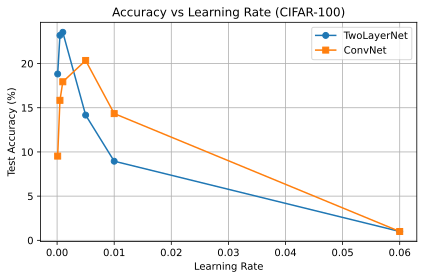

Batch=64: TwoLayerNet=21.45%, ConvNet=22.95%
Batch=128: TwoLayerNet=22.97%, ConvNet=20.41%
Batch=256: TwoLayerNet=23.48%, ConvNet=17.50%
Batch=512: TwoLayerNet=23.69%, ConvNet=16.41%
Batch=1024: TwoLayerNet=22.76%, ConvNet=12.93%


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x00000270C5B5C430>
Traceback (most recent call last):
  File "C:\Users\didi_\anaconda3\envs\torch_gpu\lib\site-packages\torch\utils\data\dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "C:\Users\didi_\anaconda3\envs\torch_gpu\lib\site-packages\torch\utils\data\dataloader.py", line 1562, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x00000270C5B5C430>
Traceback (most recent call last):
  File "C:\Users\didi_\anaconda3\envs\torch_gpu\lib\site-packages\torch\utils\data\dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "C:\Users\didi_\anaconda3\envs\torch_gpu\lib\site-packages\torch\utils\data\dataloader.py", line 1562, in _shutdown_workers
    if self._persiste

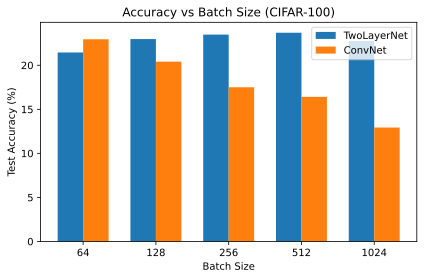

In [170]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Dataset (CIFAR-100)
# ----------------------------
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_data = datasets.CIFAR100(root='./data', train=True, download=True, transform=tfm)
test_data  = datasets.CIFAR100(root='./data', train=False, download=True, transform=tfm)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Example Model Definitions
# ----------------------------

class TwoLayerNet(nn.Module):
    def __init__(self, input_size=3*32*32, hidden_size=512, num_classes=100):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)


class ConvNet(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, 5), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(6, 16, 5), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*5*5, 120), nn.ReLU(),
            nn.Linear(120, 84), nn.ReLU(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# ----------------------------
# Helper functions
# ----------------------------
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return 100 * correct / total


def quick_train(model, lr, batch_size, epochs=3):
    loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_data, batch_size=512, shuffle=False, num_workers=2)

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
    return evaluate(model, test_loader)

# ----------------------------
# Experiment 1: Accuracy vs Learning Rate
# ----------------------------
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 0.06]
batch_size = 256

accs_lr_tln, accs_lr_cnn = [], []

for lr in learning_rates:
    accs_lr_tln.append(quick_train(TwoLayerNet(), lr=lr, batch_size=batch_size))
    accs_lr_cnn.append(quick_train(ConvNet(), lr=lr, batch_size=batch_size))
    print(f"LR={lr:.0e}: TwoLayerNet={accs_lr_tln[-1]:.2f}%, ConvNet={accs_lr_cnn[-1]:.2f}%")

plt.figure(figsize=(6,4))
plt.plot(learning_rates, accs_lr_tln, marker='o', label='TwoLayerNet')
plt.plot(learning_rates, accs_lr_cnn, marker='s', label='ConvNet')
#plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy vs Learning Rate (CIFAR-100)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("accuracy_vs_learning_rate.svg", format='svg')
plt.show()

# ----------------------------
# Experiment 2: Accuracy vs Batch Size
# ----------------------------
batch_sizes = [64, 128, 256, 512, 1024]
lr = 0.001

accs_bs_tln, accs_bs_cnn = [], []

for bs in batch_sizes:
    accs_bs_tln.append(quick_train(TwoLayerNet(), lr=lr, batch_size=bs))
    accs_bs_cnn.append(quick_train(ConvNet(), lr=lr, batch_size=bs))
    print(f"Batch={bs}: TwoLayerNet={accs_bs_tln[-1]:.2f}%, ConvNet={accs_bs_cnn[-1]:.2f}%")

x = np.arange(len(batch_sizes))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, accs_bs_tln, width, label='TwoLayerNet')
plt.bar(x + width/2, accs_bs_cnn, width, label='ConvNet')
plt.xticks(x, batch_sizes)
plt.xlabel("Batch Size")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy vs Batch Size (CIFAR-100)")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_vs_batch_size.svg", format='svg')
plt.show()


Files already downloaded and verified
Files already downloaded and verified
LR=1e-04: TwoLayerNetPlus=19.50%, ConvNetPlus=13.32%
LR=5e-04: TwoLayerNetPlus=23.39%, ConvNetPlus=26.08%
LR=1e-03: TwoLayerNetPlus=23.85%, ConvNetPlus=27.93%
LR=5e-03: TwoLayerNetPlus=22.46%, ConvNetPlus=1.00%
LR=1e-02: TwoLayerNetPlus=21.87%, ConvNetPlus=1.00%


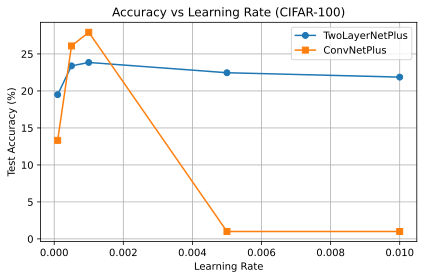

Batch=64: TwoLayerNetPlus=24.29%, ConvNetPlus=31.90%
Batch=128: TwoLayerNetPlus=23.91%, ConvNetPlus=27.05%
Batch=256: TwoLayerNetPlus=23.78%, ConvNetPlus=27.55%
Batch=512: TwoLayerNetPlus=23.81%, ConvNetPlus=25.69%
Batch=1024: TwoLayerNetPlus=22.33%, ConvNetPlus=21.44%


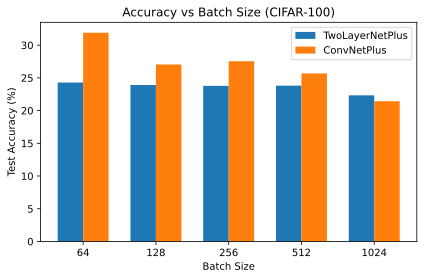

In [172]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Dataset (CIFAR-100)
# ----------------------------
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761))
])

train_data = datasets.CIFAR100(root='./data', train=True, download=True, transform=tfm)
test_data  = datasets.CIFAR100(root='./data', train=False, download=True, transform=tfm)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Model definitions
# ----------------------------

class TwoLayerNet_BNDrop(nn.Module):
    """
    Keeps the original layers:
      Linear(input -> hidden) -> ReLU
      Linear(hidden -> num_classes)
    and INSERTS two new hidden layers (hidden -> hidden) with BatchNorm and Dropout in between.
    """
    def __init__(self, input_size: int, hidden: int, num_classes: int, p: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            # original first layer
            nn.Linear(input_size, hidden), nn.ReLU(inplace=True),

            # New layer #1 (hidden -> hidden) 
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(p),

            # New layer #2 (hidden -> hidden)
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(p),

            # original final layer (kept intact: hidden -> num_classes) ---
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x.flatten(1))


class ConvNetPlus(nn.Module):
    """
    +2 layers only:
      (+1) BatchNorm2d after Conv1
      (+2) Dropout2d after Pool2
    Swaps: ReLU for Tanh, AvgPool->MaxPool, padding=2 on 5x5, GAP head.
    """
    def __init__(self, num_classes=100, drop2d=0.2, width_mult=5.0):
        super().__init__()
        c1 = max(6,   int(6   * width_mult))
        c2 = max(16,  int(16  * width_mult))
        c3 = max(120, int(120 * width_mult))
        self.features = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=5, padding=2),  # keep 32x32
            nn.BatchNorm2d(c1),                          # (+1)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 32->16

            nn.Conv2d(c1, c2, kernel_size=5, padding=2), # 16->16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 16->8
            nn.Dropout2d(drop2d),                        # (+2)

            nn.Conv2d(c2, c3, kernel_size=5, padding=2), # 8->8
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1),                     # GAP
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c3, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# ----------------------------
# Helpers
# ----------------------------
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return 100 * correct / total


def quick_train(model, lr, batch_size, epochs=3):
    loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_data, batch_size=512, shuffle=False, num_workers=2)

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
    return evaluate(model, test_loader)

# ----------------------------
# Experiment 1: Accuracy vs Learning Rate
# ----------------------------
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
batch_size = 256

accs_lr_tlnp, accs_lr_cnnp = [], []

for lr in learning_rates:
    accs_lr_tlnp.append(quick_train(TwoLayerNet_BNDrop(3 * 32 * 32, 512, 100), lr=lr, batch_size=batch_size))
    accs_lr_cnnp.append(quick_train(ConvNetPlus(), lr=lr, batch_size=batch_size))
    print(f"LR={lr:.0e}: TwoLayerNetPlus={accs_lr_tlnp[-1]:.2f}%, ConvNetPlus={accs_lr_cnnp[-1]:.2f}%")

plt.figure(figsize=(6,4))
plt.plot(learning_rates, accs_lr_tlnp, marker='o', label='TwoLayerNetPlus')
plt.plot(learning_rates, accs_lr_cnnp, marker='s', label='ConvNetPlus')
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy vs Learning Rate (CIFAR-100)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("accuracy_vs_learning_rate_plus.svg", format='svg')
plt.show()

# ----------------------------
# Experiment 2: Accuracy vs Batch Size
# ----------------------------
batch_sizes = [64, 128, 256, 512, 1024]
lr = 0.001

accs_bs_tlnp, accs_bs_cnnp = [], []

for bs in batch_sizes:
    accs_bs_tlnp.append(quick_train(TwoLayerNet_BNDrop(3 * 32 * 32, 512, 100), lr=lr, batch_size=bs))
    accs_bs_cnnp.append(quick_train(ConvNetPlus(), lr=lr, batch_size=bs))
    print(f"Batch={bs}: TwoLayerNetPlus={accs_bs_tlnp[-1]:.2f}%, ConvNetPlus={accs_bs_cnnp[-1]:.2f}%")

x = np.arange(len(batch_sizes))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, accs_bs_tlnp, width, label='TwoLayerNetPlus')
plt.bar(x + width/2, accs_bs_cnnp, width, label='ConvNetPlus')
plt.xticks(x, batch_sizes)
plt.xlabel("Batch Size")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy vs Batch Size (CIFAR-100)")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_vs_batch_size_plus.svg", format='svg')
plt.show()


<a id="section-8"></a>
### **Section 8: Visualizing the STL-10 Dataset and Preparing the Data Loader (3 points)**

In this section, you will work with a subset of the [STL-10](https://cs.stanford.edu/~acoates/stl10/) dataset, containing higher resolution images and different object classes than CIFAR-100. Before fine-tuning your ConvNet on this dataset, first complete the `visualise_stl10` function to display sample images from the following 5 classes:

1. **Bird**
2. **Deer**
3. **Dog**
4. **Horse**
5. **Monkey**

In [ ]:
def read_labels(path_to_labels):
    """
    :param path_to_labels: path to the binary file containing labels from the STL-10 dataset
    :return: an array containing the labels
    """
    with open(path_to_labels, 'rb') as f:
        labels = np.fromfile(f, dtype=np.uint8)
        return labels


def read_all_images(path_to_data):
    """
    :param path_to_data: the file containing the binary images from the STL-10 dataset
    :return: an array containing all the images
    """

    with open(path_to_data, 'rb') as f:
        # read whole file in uint8 chunks
        everything = np.fromfile(f, dtype=np.uint8)

        # We force the data into 3x96x96 chunks, since the
        # images are stored in "column-major order", meaning
        # that "the first 96*96 values are the red channel,
        # the next 96*96 are green, and the last are blue."
        # The -1 is since the size of the pictures depends
        # on the input file, and this way numpy determines
        # the size on its own.

        images = np.reshape(everything, (-1, 3, 96, 96))

        # Now transpose the images into a standard image format
        # readable by, for example, matplotlib.imshow
        # You might want to comment this line or reverse the shuffle
        # if you will use a learning algorithm like CNN, since they like
        # their channels separated.
        images = np.transpose(images, (0, 3, 2, 1))
        return images

In [ ]:
"""Taken from https://github.com/mttk/STL10/blob/master/stl10_input.py"""

from __future__ import print_function

import sys
import os, sys, tarfile, errno
import numpy as np
import matplotlib.pyplot as plt

if sys.version_info >= (3, 0, 0):
    import urllib.request as urllib # ugly but works
else:
    import urllib

try:
    from imageio import imsave
except:
    from scipy.misc import imsave

print(sys.version_info)

# image shape
HEIGHT = 96
WIDTH = 96
DEPTH = 3

# size of a single image in bytes
SIZE = HEIGHT * WIDTH * DEPTH

# path to the directory with the data
DATA_DIR = './data'

# url of the binary data
DATA_URL = 'http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz'

# path to the binary train file with image data
DATA_PATH = './data/stl10_binary/train_X.bin'

# path to the binary train file with labels
LABEL_PATH = './data/stl10_binary/train_y.bin'

def read_single_image(image_file):
    """
    CAREFUL! - this method uses a file as input instead of the path - so the
    position of the reader will be remembered outside of context of this method.
    :param image_file: the open file containing the images
    :return: a single image
    """
    # read a single image, count determines the number of uint8's to read
    image = np.fromfile(image_file, dtype=np.uint8, count=SIZE)
    # force into image matrix
    image = np.reshape(image, (3, 96, 96))
    # transpose to standard format
    # You might want to comment this line or reverse the shuffle
    # if you will use a learning algorithm like CNN, since they like
    # their channels separated.
    image = np.transpose(image, (2, 1, 0))
    return image


def plot_image(image):
    """
    :param image: the image to be plotted in a 3-D matrix format
    :return: None
    """
    plt.imshow(image)
    plt.show()

def save_image(image, name):
    imsave("%s.png" % name, image, format="png")

def download_and_extract():
    """
    Download and extract the STL-10 dataset
    :return: None
    """
    dest_directory = DATA_DIR
    if not os.path.exists(dest_directory):
        os.makedirs(dest_directory)
    filename = DATA_URL.split('/')[-1]
    filepath = os.path.join(dest_directory, filename)
    if not os.path.exists(filepath):
        def _progress(count, block_size, total_size):
            sys.stdout.write('\rDownloading %s %.2f%%' % (filename,
                float(count * block_size) / float(total_size) * 100.0))
            sys.stdout.flush()
        filepath, _ = urllib.urlretrieve(DATA_URL, filepath, reporthook=_progress)
        print('Downloaded', filename)
        tarfile.open(filepath, 'r:gz').extractall(dest_directory)

def save_images(images, labels):
    print("Saving images to disk")
    i = 0
    for image in images:
        label = labels[i]
        directory = './img/' + str(label) + '/'
        try:
            os.makedirs(directory, exist_ok=True)
        except OSError as exc:
            if exc.errno == errno.EEXIST:
                pass
        filename = directory + str(i)
        print(filename)
        save_image(image, filename)
        i = i+1
    
if __name__ == "__main__":
    # download data if needed
    download_and_extract()

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def visualise_stl10_generate_latex(class_mapping):
    '''
    Visualizes and saves 5 images from each specified class in the STL-10 dataset,
    and generates LaTeX code for displaying the images in a 5-column layout.

    Args:
        class_mapping (dict): A dictionary mapping class indices to class names.
    '''

    DATA_PATH = './data/stl10_binary/train_X.bin'
    LABEL_PATH = './data/stl10_binary/train_y.bin'
    OUTPUT_DIR = './stl10_samples'

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    images = read_all_images(DATA_PATH)
    labels = read_labels(LABEL_PATH)

    latex_code = []

    for class_idx, class_name in class_mapping.items():
        sample_idx = np.where(labels == class_idx)[0][:5]

        # Create visualization for quick checking
        plt.figure(figsize=(15, 3))

        image_paths = []

        for i, idx in enumerate(sample_idx):
            img = images[idx]

            # Save image
            file_name = f"{class_name}_{i+1}.png"
            file_path = os.path.join(OUTPUT_DIR, file_name)
            Image.fromarray(img).resize((96, 96), Image.NEAREST).save(file_path)
            image_paths.append(file_name)

            # Plot preview
            plt.subplot(1, 5, i + 1)
            plt.imshow(img)
            plt.axis('off')
            if i == 2:
                plt.title(class_name)

        plt.show()

        # Build LaTeX for this class
        latex_code.append(f"% --- {class_name} ---")
        latex_code.append("\\begin{figure}[h!]")
        latex_code.append("\\centering")

        for img_file in image_paths:
            latex_code.append(
                f"\\includegraphics[width=0.18\\textwidth]{{figures/stl10_samples/{img_file}}}"
            )

        latex_code.append(f"\\caption{{Example images for class {class_name}}}")
        latex_code.append(f"\\label{{fig:stl10_{class_name.lower()}}}")
        latex_code.append("\\end{figure}")
        latex_code.append("")  # spacing

    # Print LaTeX for easy copy-paste
    print("\n".join(latex_code))


In [ ]:
# Define the class mapping for bird, deer, dog, horse, and monkey
class_mapping = {2: 'bird', 5: 'deer', 6: 'dog', 7: 'horse', 8: 'monkey'}

# Visualize STL-10 classes
visualise_stl10_generate_latex(class_mapping)

After visualizing the data, implement the `STL10_loader` class to create a custom data loader that initializes the dataset, extracts the target classes, and applies the necessary image transformations. Once these tasks are completed, you will move on to fine-tuning the ConvNet on this dataset in the next section.

In [ ]:
class STL10_loader(Dataset):
    _path_dict = {
        'train': {
            'data': './data/stl10_binary/train_X.bin',
            'labels': './data/stl10_binary/train_y.bin'
        },
        'test': {
            'data': './data/stl10_binary/test_X.bin',
            'labels': './data/stl10_binary/test_y.bin'
        }
    }

    _original_class_mapping = {
        2: 'bird', 5: 'deer', 6: 'dog', 7: 'horse', 8: 'monkey'
    }

    _original_to_new_class_idx = {
        orig: new for new, orig in enumerate(_original_class_mapping.keys())
    }
    
    def __init__(self, root, train=True, transform=None):
        '''
        Initializes the STL10 dataset.

        Args:
            root (str): Root directory of the dataset.
            train (bool): If True, use the training set, otherwise use the test set.
            transform (callable, optional): A function/transform to apply to the images.
        '''

        # YOUR CODE HERE
        self.root = root
        self.train = train
        self.transform = transform

        # Pre-load images and labels
        self.images: np.ndarray = read_all_images(self._path_dict['train' if train else 'test']['data'])
        self.labels: np.ndarray = read_labels(self._path_dict['train' if train else 'test']['labels']) - 1  # Convert to 0-based indexing

        # Filter to only include specified classes
        mask = np.isin(self.labels, list(self._original_class_mapping.keys()))
        self.images = self.images[mask]
        self.labels = self.labels[mask]

        # Remap labels to new indices
        self.labels = np.array([self._original_to_new_class_idx[label] for label in self.labels])

        # Turn labels into one-hot encoded torch tensors
        self.labels = torch.tensor(self.labels, dtype=torch.long)
        # self.labels = F.one_hot(self.labels, num_classes=len(self._original_class_mapping)).float()

    def __len__(self):
        '''
        Returns the number of samples in the dataset.
        '''
        # YOUR CODE HERE
        return len(self.images)

    def __getitem__(self, idx):
        '''
        Retrieves a sample from the dataset at the specified index.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            tuple: A tuple containing the transformed image and its target label.
        '''

        # Read image
        image = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

<a id="section-9"></a>
### **Section 9: Fine-tuning ConvNet on STL-10 (14 points)**

In this section, you will load the pre-trained parameters of the ConvNet (trained on CIFAR-100) and modify the output layer to adapt it to the new dataset containing 5 classes. You can either first load the pre-trained parameters and then modify the output layer, or change the output layer before loading the matched pre-trained parameters. Once modified, you will train the model and document the settings of hyperparameters, accuracy, and learning curve. Additionally, visualize both the training loss and accuracy to assess the learning process. To gain a deeper understanding of the feature learning process, consider using techniques like [**t-sne**](https://lvdmaaten.github.io/tsne/) for feature space visualization.

In [21]:
# YOUR CODE HERE

<a id="section-10"></a>
### **Section 10: Bonus Challenge (optional)**

Try to achieve the highest possible accuracy on the test dataset (5 classes from STL-10) by adjusting hyperparameters, modifying architectures, or applying techniques like data augmentation. The top-performing teams will earn bonus points that can significantly boost their final lab grade, even allowing it to exceed 10 (up to 11):

- **1st place:** +1.0 to the final grade of the final lab
- **2nd place:** +0.8 to the final grade of the final lab
- **3rd place:** +0.6 to the final grade of the final lab
- **4th place:** +0.4 to the final grade of the final lab
- **5th place:** +0.2 to the final grade of the final lab

**Hint:** You may use techniques like data augmentation, freezing early layers, modifying architecture, or optimizing hyperparameters. Only data from CIFAR-100 and STL-10 can be used, and you cannot add more than 3 additional convolutional layers.

In [22]:
# YOUR CODE HERE

<a id="section-x"></a>
### **Section X: Individual Contribution Report *(Mandatory)***

Because we want each student to contribute fairly to the submitted work, we ask you to fill out the textcells below. Write down your contribution to each of the assignment components in percentages. Naturally, percentages for one particular component should add up to 100% (e.g. 30% - 30% - 40%). No further explanation has to be given.

| Name | Contribution on Research | Contribution on Programming | Contribution on Writing |
| -------- | ------- | ------- | ------- |
| Daniel Otero Gomez | 33 % | 33 % | 33 % |
| Daniel Amidirad | 33 % | 33 % | 33 % |
| Miguel Aldea Mendes | 33 % | 33 % | 33 % |


### - End of Notebook -